In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score

from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv('ecommerce_sales_data.csv')
# df.head()
# df.info()
# df['Category'].value_counts()

df.loc[df['Profit'] < 0]

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
1804,2023-02-10,Camera,Electronics,West,7,5355.07,-2603.38
2024,2023-08-24,Keyboard,Accessories,South,4,3788.24,-7662.67


In [3]:
df.sort_values(by = 'Order Date').tail(50)
# temp = df.loc[:,'Order Date'].replace('NaN',pd.NA)
# temp.sort_values()
# empty = df.loc[:,'Order Date']
# empty = empty[empty.isna()]
# empty.head()

df = df.dropna(subset = 'Order Date')
df.sort_values(by = 'Order Date').tail(10)
df.describe()

,Quantity,Sales,Profit
count,3124.000000,3124.000000,3124.000000
mean,5.206146,3374.265317,584.167319
std,4.464728,5312.306448,1049.986117
min,-1.000000,28.410000,-7662.670000
25%,2.000000,1028.320000,153.692500
50%,5.000000,2328.580000,358.887500
75%,7.000000,4551.287500,739.236250
max,168.000000,180690.470000,35223.070000


In [4]:
# df.info()
# df.sort_values(by = 'Product Name')
df['Product Name'] = df['Product Name'].replace(['#NAME','NaN'],pd.NA)
# df.sort_values(by = 'Product Name')
df = df.dropna(subset = 'Product Name')

# df.sort_values(by = 'Product Name')
# df.info()

In [5]:
df.sort_values(by = 'Category')


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
1495,2024-12-28,Null,,North,5,180690.47,35223.07
3130,2022-06-28,Smartwatch,,West,5,990.93,87.61
1697,2024-09-28,Monitor,Accessories,East,1,359.80,78.17
1696,2022-05-18,Headphones,Accessories,North,3,2256.09,282.52
1695,2023-12-24,Monitor,Accessories,South,1,1162.00,210.87
...,...,...,...,...,...,...,...
1884,2022-03-10,Keyboard,NaN,South,9,1764.54,417.95
2018,2024-08-08,Headphones,NaN,South,8,2592.46,526.38
2116,2023-04-16,Smartwatch,NaN,South,4,776.22,73.16
2856,2022-11-24,Null,NaN,South,6,3504.62,980.70


In [6]:
df = df.replace(r"^\s*$", "", regex=True)
df['Category'] = df['Category'].replace(['','NaN','na','Null'],pd.NA)
df=  df.dropna()
df.sort_values(by = 'Category')

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2022-11-27,Mouse,Accessories,East,3,598.665,53.265
1698,2022-09-26,Mouse,Accessories,South,8,4248.840,831.540
1697,2024-09-28,Monitor,Accessories,East,1,359.800,78.170
1696,2022-05-18,Headphones,Accessories,North,3,2256.090,282.520
1695,2023-12-24,Monitor,Accessories,South,1,1162.000,210.870
...,...,...,...,...,...,...,...
2438,2023-08-23,Printer,Office,West,7,7119.280,1555.050
2506,2023-03-06,Printer,Office,South,8,4696.750,410.030
2695,2022-01-16,Printer,Office,North,4,4428.890,600.550
2220,2023-12-29,Printer,Office,West,2,340.150,59.560


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.info()
df['Order Date'].value_counts()

<class 'pandas.DataFrame'>
Index: 3086 entries, 0 to 3139
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3086 non-null   datetime64[us]
 1   Product Name  3086 non-null   str           
 2   Category      3086 non-null   str           
 3   Region        3086 non-null   str           
 4   Quantity      3086 non-null   int64         
 5   Sales         3086 non-null   float64       
 6   Profit        3086 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 192.9 KB


Order Date
2023-08-12    10
2024-05-24    10
2024-05-17    10
2024-03-04     9
2022-10-20     9
              ..
2024-02-27     1
2024-11-05     1
2022-12-16     1
2023-10-06     1
2022-04-12     1
Name: count, Length: 1026, dtype: int64

In [8]:
df.sort_values(by = 'Region')
df.info()

<class 'pandas.DataFrame'>
Index: 3086 entries, 0 to 3139
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3086 non-null   datetime64[us]
 1   Product Name  3086 non-null   str           
 2   Category      3086 non-null   str           
 3   Region        3086 non-null   str           
 4   Quantity      3086 non-null   int64         
 5   Sales         3086 non-null   float64       
 6   Profit        3086 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 192.9 KB


In [9]:
df['Category'] = df['Category'].astype('category')
df.info()

<class 'pandas.DataFrame'>
Index: 3086 entries, 0 to 3139
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3086 non-null   datetime64[us]
 1   Product Name  3086 non-null   str           
 2   Category      3086 non-null   category      
 3   Region        3086 non-null   str           
 4   Quantity      3086 non-null   int64         
 5   Sales         3086 non-null   float64       
 6   Profit        3086 non-null   float64       
dtypes: category(1), datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 171.8 KB


In [10]:
df.describe()

,Order Date,Quantity,Sales,Profit
count,3086,3086.000000,3086.000000,3086.000000
mean,2023-07-12 00:42:27.764096,5.202852,3223.404543,555.817477
min,2022-01-01 00:00:00,-1.000000,28.410000,-7662.670000
25%,2022-10-14 00:00:00,2.000000,1027.622500,153.595000
50%,2023-07-19 12:00:00,5.000000,2320.160000,357.900000
75%,2024-04-15 00:00:00,7.000000,4535.687500,735.442500
max,2024-12-31 00:00:00,168.000000,30470.070000,5676.899000
std,NaN,4.484478,3010.604611,639.363738


In [11]:
mask_neg = df['Quantity']<= 0
df = df[~mask_neg]
df.describe()

,Order Date,Quantity,Sales,Profit
count,3043,3043.000000,3043.000000,3043.000000
mean,2023-07-14 00:10:24.646730,5.277029,3260.574165,562.239068
min,2022-01-01 00:00:00,1.000000,53.200000,-7662.670000
25%,2022-10-16 12:00:00,3.000000,1061.425000,160.435000
50%,2023-07-22 00:00:00,5.000000,2367.650000,362.680000
75%,2024-04-17 00:00:00,7.000000,4557.060000,742.495000
max,2024-12-31 00:00:00,168.000000,30470.070000,5676.899000
std,NaN,4.472043,3012.383086,641.102397


In [12]:
mask_neg = df['Profit']<= 0
df = df[~mask_neg]
df.describe()

,Order Date,Quantity,Sales,Profit
count,3041,3041.000000,3041.000000,3041.000000
mean,2023-07-14 01:03:55.580401,5.276883,3259.711896,565.984720
min,2022-01-01 00:00:00,1.000000,53.200000,6.000000
25%,2022-10-16 00:00:00,3.000000,1060.820000,160.840000
50%,2023-07-22 00:00:00,5.000000,2362.600000,362.810000
75%,2024-04-17 00:00:00,7.000000,4556.600000,742.680000
max,2024-12-31 00:00:00,168.000000,30470.070000,5676.899000
std,NaN,4.473344,3013.119064,621.062975


In [13]:
df.info()
# df.info()
# print(df)
df = df.reset_index(drop = True)
print(df)
df.info()


<class 'pandas.DataFrame'>
Index: 3041 entries, 0 to 3139
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3041 non-null   datetime64[us]
 1   Product Name  3041 non-null   str           
 2   Category      3041 non-null   category      
 3   Region        3041 non-null   str           
 4   Quantity      3041 non-null   int64         
 5   Sales         3041 non-null   float64       
 6   Profit        3041 non-null   float64       
dtypes: category(1), datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 169.3 KB
     Order Date Product Name     Category Region  Quantity      Sales  \
0    2022-11-27        Mouse  Accessories   East         3    598.665   
1    2022-05-11       Tablet  Electronics  South         5   5865.570   
2    2024-03-16        Mouse  Accessories  South         1    393.480   
3    2023-12-01       Camera  Electronics   West         1    524.380   
4  

In [14]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2022-11-27,Mouse,Accessories,East,3,598.665,53.265
1,2022-05-11,Tablet,Electronics,South,5,5865.570,502.730
2,2024-03-16,Mouse,Accessories,South,1,393.480,101.435
3,2023-12-01,Camera,Electronics,West,1,524.380,106.350
4,2023-10-09,Headphones,Accessories,North,7,6167.320,1027.980


In [15]:
df['Region'] = df['Region'].astype('category')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3041 entries, 0 to 3040
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3041 non-null   datetime64[us]
 1   Product Name  3041 non-null   str           
 2   Category      3041 non-null   category      
 3   Region        3041 non-null   category      
 4   Quantity      3041 non-null   int64         
 5   Sales         3041 non-null   float64       
 6   Profit        3041 non-null   float64       
dtypes: category(2), datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 124.9 KB


In [16]:
df['Product Name'].value_counts()

Product Name
Monitor       359
Camera        358
Smartwatch    356
Tablet        343
Laptop        332
Keyboard      325
Smartphone    322
Mouse         320
Headphones    221
Printer       105
Name: count, dtype: int64

              Quantity
Product Name          
Camera            1768
Headphones        1045
Keyboard          1201
Laptop            2622
Monitor           1850
Mouse             1236
Printer            517
Smartphone        2342
Smartwatch        1774
Tablet            1692


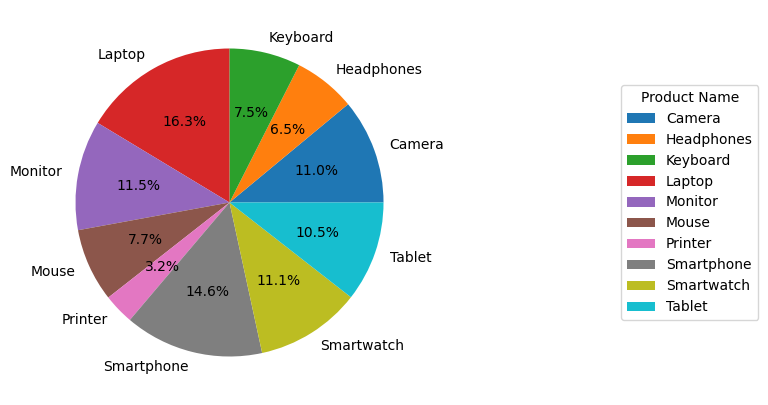

In [17]:
pro_name_quan = df.groupby('Product Name').agg({'Quantity':'sum'})
print(pro_name_quan)
pie = pro_name_quan.plot(kind = 'pie',y ='Quantity' ,figsize = (5,5),autopct = "%1.1f%%",ylabel = "")

pie.legend(
    loc="center left",
    bbox_to_anchor=(1.5, 0.5),
    title="Product Name"
)

plt.show()


                    Sales
Product Name             
Camera        1159674.680
Headphones     643729.200
Keyboard       762165.645
Laptop        1484361.850
Monitor       1144184.860
Mouse          777239.440
Printer        321709.990
Smartphone    1560625.150
Smartwatch    1034028.220
Tablet        1025064.840


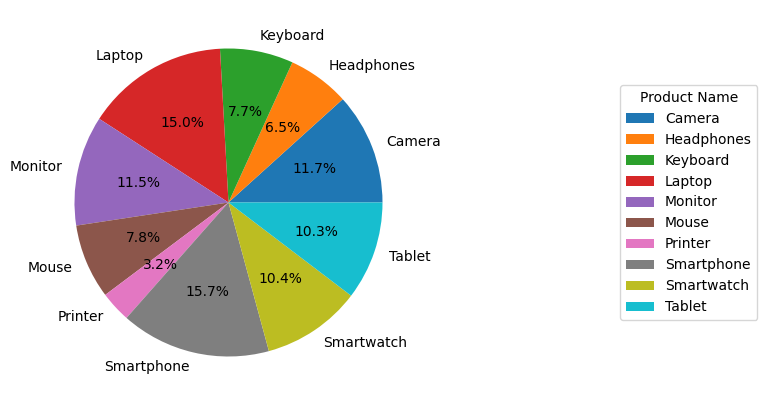

In [18]:
pro_name_sales = df.groupby('Product Name').agg({'Sales':'sum'})
print(pro_name_sales)
pie = pro_name_sales.plot(kind = 'pie',y ='Sales' ,figsize = (5,5),autopct = "%1.1f%%",ylabel = "")

pie.legend(
    loc="center left",
    bbox_to_anchor=(1.5, 0.5),
    title="Product Name"
)

plt.show()


                  Profit
Product Name            
Camera        204189.020
Headphones    111125.290
Keyboard      130444.550
Laptop        276520.370
Monitor       199451.780
Mouse         132516.985
Printer        51843.750
Smartphone    269517.460
Smartwatch    176229.430
Tablet        169320.899


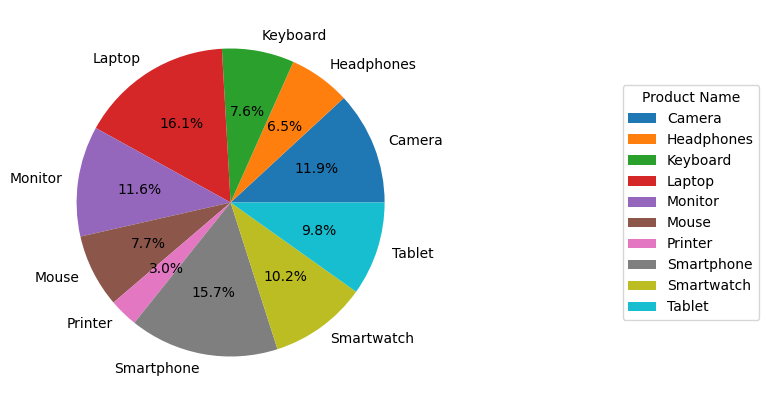

In [19]:
pro_name_sales = df.groupby('Product Name').agg({'Profit':'sum'})
print(pro_name_sales)
pie = pro_name_sales.plot(kind = 'pie',y ='Profit' ,figsize = (5,5),autopct = "%1.1f%%",ylabel = "")

pie.legend(
    loc="center left",
    bbox_to_anchor=(1.5, 0.5),
    title="Product Name"
)

plt.show()


In [20]:
mask = df['Product Name'] == 'Laptop'
df.loc[mask].sort_values(by = 'Profit')
df.loc[mask].describe()

# df.loc[mask]['Profit'].plot(kind = 'box',ylabel = 'Euro',figsize = (8,8))

,Order Date,Quantity,Sales,Profit
count,332,332.000000,332.000000,332.000000
mean,2023-08-07 19:05:03.614457,7.897590,4470.969428,832.892681
min,2022-01-04 00:00:00,1.000000,53.200000,6.000000
25%,2022-12-01 18:00:00,4.000000,1227.027500,182.557500
50%,2023-08-15 12:00:00,6.000000,3088.850000,485.550000
75%,2024-05-06 06:00:00,10.000000,6474.047500,1191.442500
max,2024-12-29 00:00:00,168.000000,21547.900000,5542.980000
std,NaN,10.091503,4301.896206,957.754429


<Axes: ylabel='Euro'>

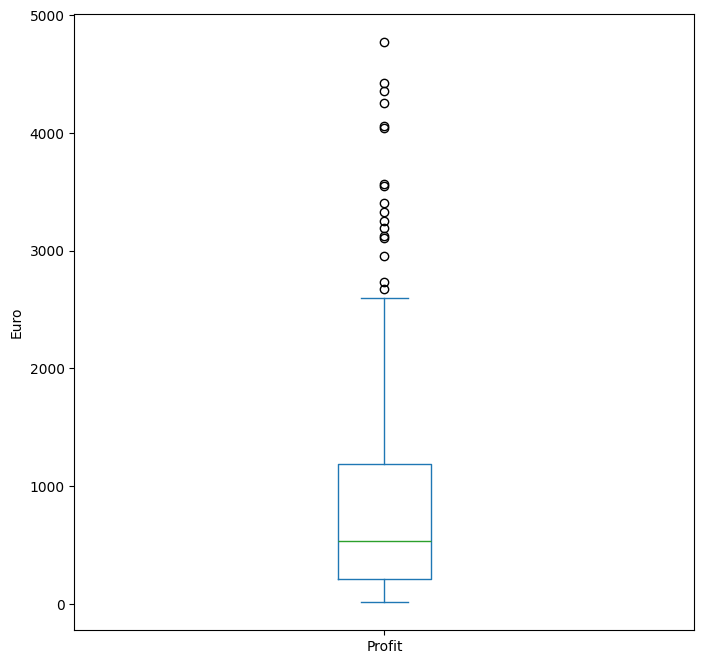

In [21]:
mask = df['Product Name'] == 'Smartphone'
df.loc[mask].sort_values(by = 'Profit')
df.loc[mask].describe()

df.loc[mask]['Profit'].plot(kind = 'box',ylabel = 'Euro',figsize = (8,8))

In [22]:
'''
1.遍历所有产品类别
2.对每个产品类别，查找outlier mask
3.删除
''';
def outlier_mask(s: pd.Series):
    '''
    1.找两个分位,算IQR，算上下界
    2.做mask
    删数据
    '''
    quantile1 = s.quantile(0.25)
    quantile2 = s.quantile(0.75)
    iqr = quantile2 - quantile1

    upperBound = quantile2 + 1.5*iqr
    lowerBound = quantile1 - 1.5*iqr

    # mask = (s>upperBound) | (s < lowerBound)
    mask = (s>upperBound)

    return mask

def drop_outlier_perProduct(df:pd.DataFrame,outlier_index:list,outlier:pd.DataFrame):

    outlier_index = []
    
    for name in df['Product Name'].unique():
        
        mask = df['Product Name'] == name
        
        temp = df.loc[mask]['Sales']
        innormalSales = outlier_mask(temp)

        df.loc[mask]['Profit']
        innormalProfit = outlier_mask(df.loc[mask]['Profit'])

        outlier = innormalSales | innormalProfit

        outlier_index.extend(temp[outlier].index)

    outlier = df.loc[outlier_index]
    df = df.drop(index=outlier_index)
    return df,outlier_index,outlier

all_data = df.copy()
df.info()
outlier_index = []
outlier = None
df,outlier_index,outlier = drop_outlier_perProduct(df,outlier_index,outlier)
df.info()
# df.loc[outlier_index].describe()
df = df.reset_index()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3041 entries, 0 to 3040
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3041 non-null   datetime64[us]
 1   Product Name  3041 non-null   str           
 2   Category      3041 non-null   category      
 3   Region        3041 non-null   category      
 4   Quantity      3041 non-null   int64         
 5   Sales         3041 non-null   float64       
 6   Profit        3041 non-null   float64       
dtypes: category(2), datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 124.9 KB
<class 'pandas.DataFrame'>
Index: 2834 entries, 0 to 3039
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    2834 non-null   datetime64[us]
 1   Product Name  2834 non-null   str           
 2   Category      2834 non-null   category      
 3   Region        2834

In [23]:
# 添加 年，年-月，季度 三个新列，并重新排列顺序

df['Year'] = df['Order Date'].dt.to_period('Y')
df['Year-Month'] = df['Order Date'].dt.to_period('M')
df['Quarter'] = df['Order Date'].dt.to_period('Q')
df['Product Name'] = df['Product Name'].astype('category')
df['Unit Price'] = df['Sales']/df['Quantity']
df['Profit Margin'] = df['Profit']/df['Sales']
# df.head()

df = df[['Year','Quarter','Year-Month','Order Date','Region','Category','Product Name','Unit Price','Quantity','Sales','Profit'	,'Profit Margin']]
df = df.sort_values(by=['Year','Quarter','Year-Month','Order Date']).reset_index(drop = True)
df.to_csv('cleaned_padded_data.csv')

In [24]:
# 计算单价与销售利润率

df['Unit Price'] = df['Sales']/df['Quantity']
df['Profit Margin'] = df['Profit']/df['Sales']
df.head()

,Year,Quarter,Year-Month,Order Date,Region,Category,Product Name,Unit Price,Quantity,Sales,Profit,Profit Margin
0,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Mouse,1158.280000,3,3474.840,565.000,0.162597
1,2022,2022Q1,2022-01,2022-01-01,South,Accessories,Monitor,162.031250,8,1296.250,273.970,0.211356
2,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Keyboard,1062.100000,6,6372.600,570.750,0.089563
3,2022,2022Q1,2022-01,2022-01-02,North,Accessories,Mouse,825.098750,4,3300.395,180.225,0.054607
4,2022,2022Q1,2022-01,2022-01-03,North,Electronics,Camera,389.022857,7,2723.160,638.260,0.234382


In [25]:
# 1.销售额相关


# 三年总销售额
overall_sales = df['Sales'].sum()
print(overall_sales)

# 平均每年销售额
avg_sales = overall_sales/3
print(avg_sales)

# 每年销售额
print(df.groupby('Year').agg({'Sales':'sum'}))

# 每月销售额
monthly_sales = df.groupby('Year-Month').agg({'Sales':'sum'}).sort_values(by = 'Year-Month').reset_index()
# monthly_sales.plot(kind ='line', x = 'Year-Month',y ='Sales',ylabel= 'Sales', figsize = (20,5))
# plt.show()
# monthly_sales.to_csv('monthly_sales.csv')

# 每季度销售额
quarterly_sales = df.groupby('Quarter').agg({'Sales':'sum'}).sort_values(by = 'Quarter').reset_index()
# quarterly_sales.plot(kind ='line', x = 'Quarter',y ='Sales',ylabel= 'Sales', figsize = (20,5))
# plt.show()
# quarterly_sales.to_csv('quarterly_sales.csv')

df.info()

7941206.13
2647068.71
            Sales
Year             
2022  2441843.550
2023  2721502.895
2024  2777859.685
<class 'pandas.DataFrame'>
RangeIndex: 2834 entries, 0 to 2833
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Year           2834 non-null   period[Y-DEC] 
 1   Quarter        2834 non-null   period[Q-DEC] 
 2   Year-Month     2834 non-null   period[M]     
 3   Order Date     2834 non-null   datetime64[us]
 4   Region         2834 non-null   category      
 5   Category       2834 non-null   category      
 6   Product Name   2834 non-null   category      
 7   Unit Price     2834 non-null   float64       
 8   Quantity       2834 non-null   int64         
 9   Sales          2834 non-null   float64       
 10  Profit         2834 non-null   float64       
 11  Profit Margin  2834 non-null   float64       
dtypes: category(3), datetime64[us](1), float64(4), int64(1), period[M](1), pe

In [26]:
# 2.利润相关

# 三年总利润
overall_profit = df['Profit'].sum()
# print(overall_profit)

# 平均每年利润
avg_profit = overall_profit/3
# print(avg_profit)

# 每年利润
# print(df.groupby('Year').agg({'Profit':'sum'}))

# 每月利润
monthly_profit = df.groupby('Year-Month').agg({'Profit':'sum'}).sort_values(by = 'Year-Month').reset_index()
# print(monthly_profit)
# monthly_profit.plot(kind ='line', x = 'Year-Month',y ='Profit',ylabel= 'Profit', figsize = (20,5))
# plt.show()
# monthly_profit.to_csv('monthly_profit.csv')

# 每季度利润
quarterly_profit = df.groupby('Quarter').agg({'Profit':'sum'}).sort_values(by = 'Quarter').reset_index()
# quarterly_profit.plot(kind ='line', x = 'Quarter',y ='Profit',ylabel= 'Profit', figsize = (20,5))
# plt.show()
# quarterly_profit.to_csv('quarterly_profit.csv')

In [27]:
# 3.销售利润率相关

# 三年总销售利润率
overall_profit_margin = overall_sales/overall_profit
# print(overall_profit_margin)

# 每年销售利润率
profit_margin_per_year = (df.groupby('Year').agg({'Profit':'sum'}).sort_values(by = 'Year')['Profit']/df.groupby('Year').agg({'Sales':'sum'}).sort_values(by = 'Year')['Sales']).rename('Profit Margin').reset_index()
# profit_margin_per_year 

# 每季度销售利润率
profit_margin_per_quarter =  df.groupby('Quarter').agg(
    {'Profit':'sum','Sales':'sum'}
).reset_index()
profit_margin_per_quarter['Profit Margin'] = profit_margin_per_quarter['Profit']/profit_margin_per_quarter['Sales']
profit_margin_per_quarter = profit_margin_per_quarter[['Quarter','Profit Margin']]
# profit_margin_per_quarter
profit_margin_per_quarter.to_csv('profit_margin_per_quarter.csv')

# 每月销售利润率
profit_margin_per_month =  df.groupby('Year-Month').agg(
    {'Profit':'sum','Sales':'sum'}
).reset_index()
profit_margin_per_month['Profit Margin'] = profit_margin_per_month['Profit']/profit_margin_per_month['Sales']
profit_margin_per_month = profit_margin_per_month[['Year-Month','Profit Margin']]
# profit_margin_per_month
# profit_margin_per_month.to_csv('profit_margin_per_month.csv')


In [28]:
# 地区相关

# 各地区各自总销售额
sales_each_region = df.groupby('Region').agg({'Sales':'sum'}).reset_index()
sales_each_region

# 各地区各自总利润
profit_each_region = df.groupby('Region').agg({'Profit':'sum'}).reset_index()
profit_each_region

# 各地区各自总利润
profit_margin_each_region = df.groupby('Region').agg({'Sales':'sum','Profit':'sum'}).reset_index()
profit_margin_each_region['Profit Margin'] = profit_margin_each_region['Profit']/profit_margin_each_region['Sales']
profit_margin_each_region = profit_margin_each_region[['Region','Profit Margin']]
profit_margin_each_region

,Region,Profit Margin
0,East,0.163682
1,North,0.165197
2,South,0.163895
3,West,0.164280


In [29]:
annual_summary = df.groupby('Year').agg({'Sales':'sum','Profit':'sum'})
annual_summary['Profit Margin'] = annual_summary['Profit']/annual_summary['Sales']
# annual_summary['Sales Growth Rate'] = (annual_summary['Sales'] - annual_summary['Sales'].shift(1))/annual_summary['Sales'].shift(1)
annual_summary['Sales Growth Rate'] = annual_summary['Sales'].pct_change()
annual_summary['Profit Growth Rate'] = annual_summary['Profit'].pct_change()
annual_summary['Profit Margin Change'] = annual_summary['Profit Margin'] - annual_summary['Profit Margin'].shift()


annual_summary = annual_summary.reset_index()
annual_summary = annual_summary[['Year'	,'Sales',	'Sales Growth Rate' ,'Profit' ,'Profit Growth Rate','Profit Margin' ,'Profit Margin Change']]
annual_summary

# print((564328.835- 529579.360)/529579.360)

,Year,Sales,Sales Growth Rate,Profit,Profit Growth Rate,Profit Margin,Profit Margin Change
0,2022,2441843.550,NaN,411430.770,NaN,0.168492,NaN
1,2023,2721502.895,0.114528,451579.225,0.097583,0.165930,-0.002562
2,2024,2777859.685,0.020708,441307.465,-0.022746,0.158866,-0.007064


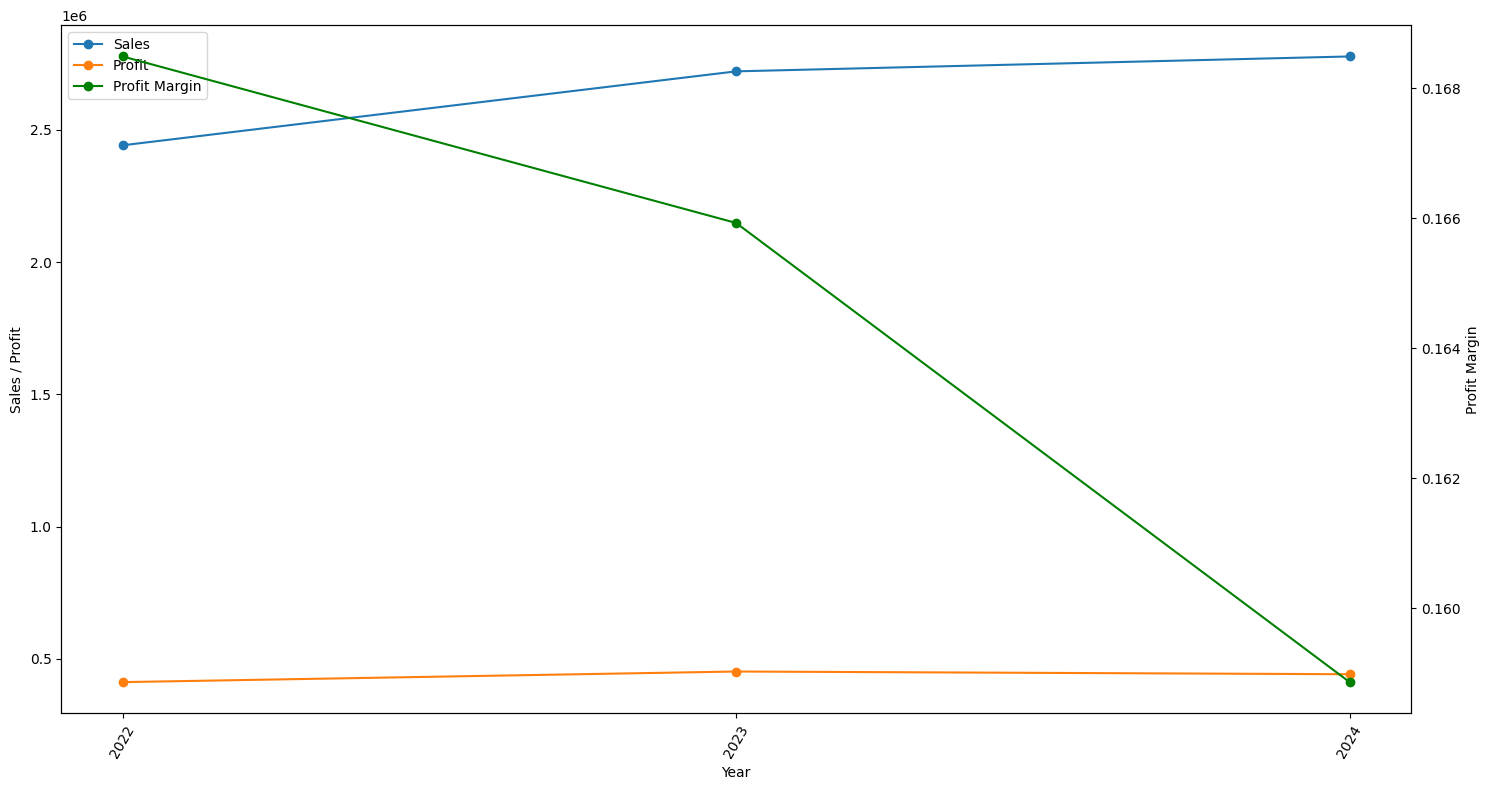

In [30]:
fig, ax1 = plt.subplots(figsize=(15, 8))

x = annual_summary['Year'].astype(str)

ax1.plot(x, annual_summary['Sales'], marker='o', label='Sales')
ax1.plot(x, annual_summary['Profit'], marker='o', label='Profit')

ax2 = ax1.twinx()
ax2.plot(x, annual_summary['Profit Margin'], marker='o', color='green', label='Profit Margin')

ax1.set_xlabel('Year')
ax1.set_ylabel('Sales / Profit')
ax2.set_ylabel('Profit Margin')

# 关键：让 ax1 的 x 轴标签旋转
ax1.tick_params(axis='x', labelrotation=60)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='best'
)

plt.tight_layout()
plt.show()

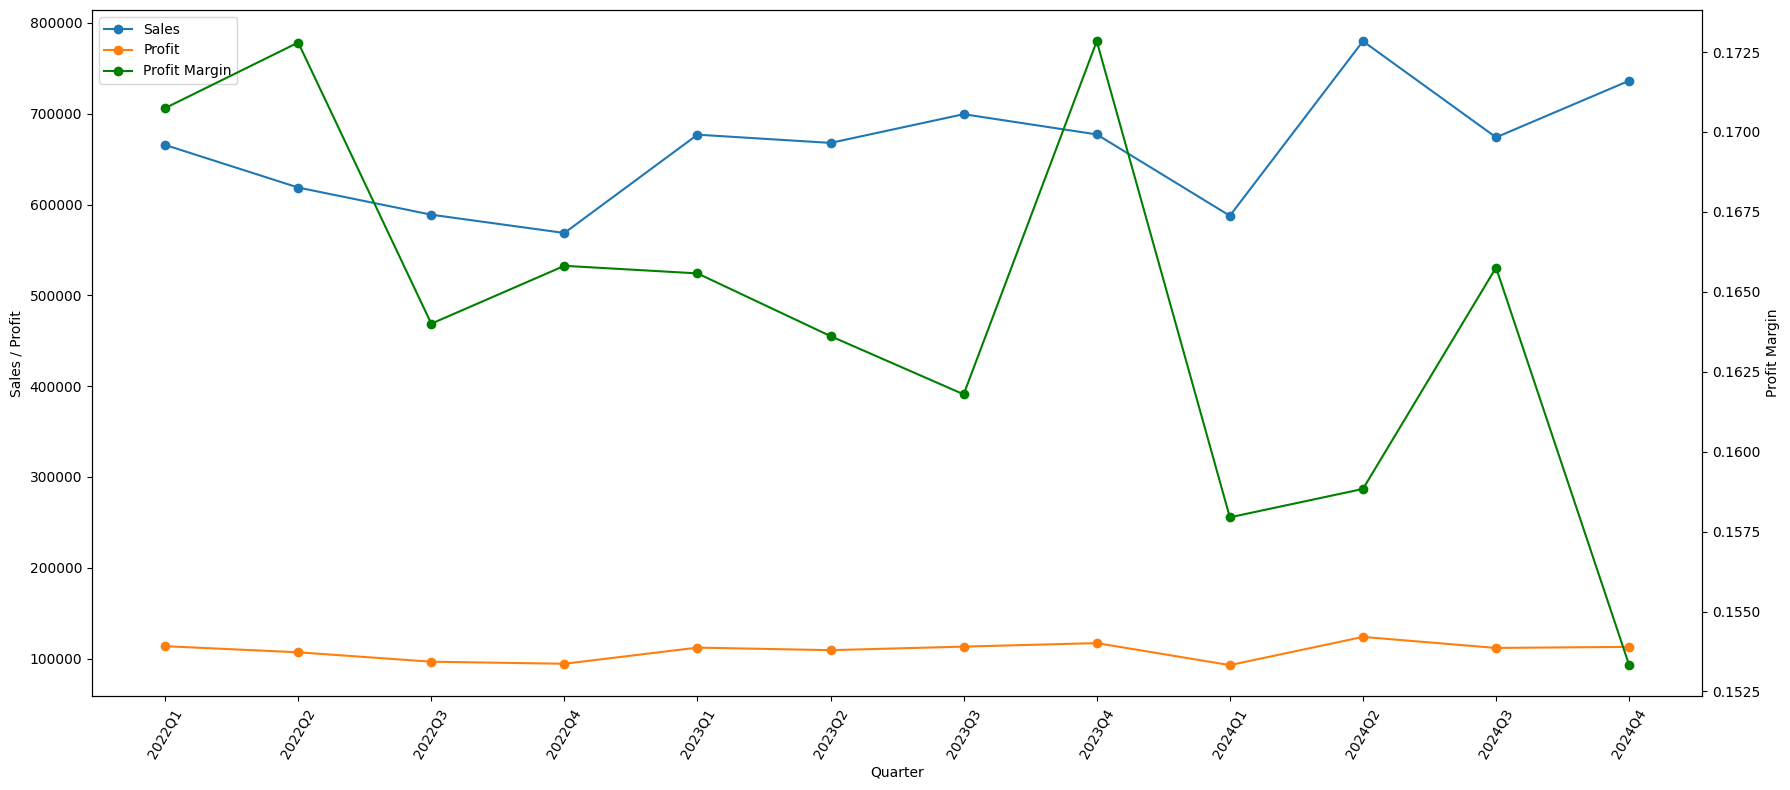

In [31]:
quarterly_summary = df.groupby('Quarter').agg({'Sales':'sum','Profit':'sum'})
quarterly_summary['Profit Margin'] = quarterly_summary['Profit']/quarterly_summary['Sales']
quarterly_summary = quarterly_summary.reset_index()

fig, ax1 = plt.subplots(figsize=(18, 8))

x = quarterly_summary['Quarter'].astype(str)

ax1.plot(x, quarterly_summary['Sales'], marker='o', label='Sales')
ax1.plot(x, quarterly_summary['Profit'], marker='o', label='Profit')

ax2 = ax1.twinx()
ax2.plot(x, quarterly_summary['Profit Margin'], marker='o', color='green', label='Profit Margin')

ax1.set_xlabel('Quarter')
ax1.set_ylabel('Sales / Profit')
ax2.set_ylabel('Profit Margin')

# 关键：让 ax1 的 x 轴标签旋转
ax1.tick_params(axis='x', labelrotation=60)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='best'
)

plt.tight_layout()
plt.show()


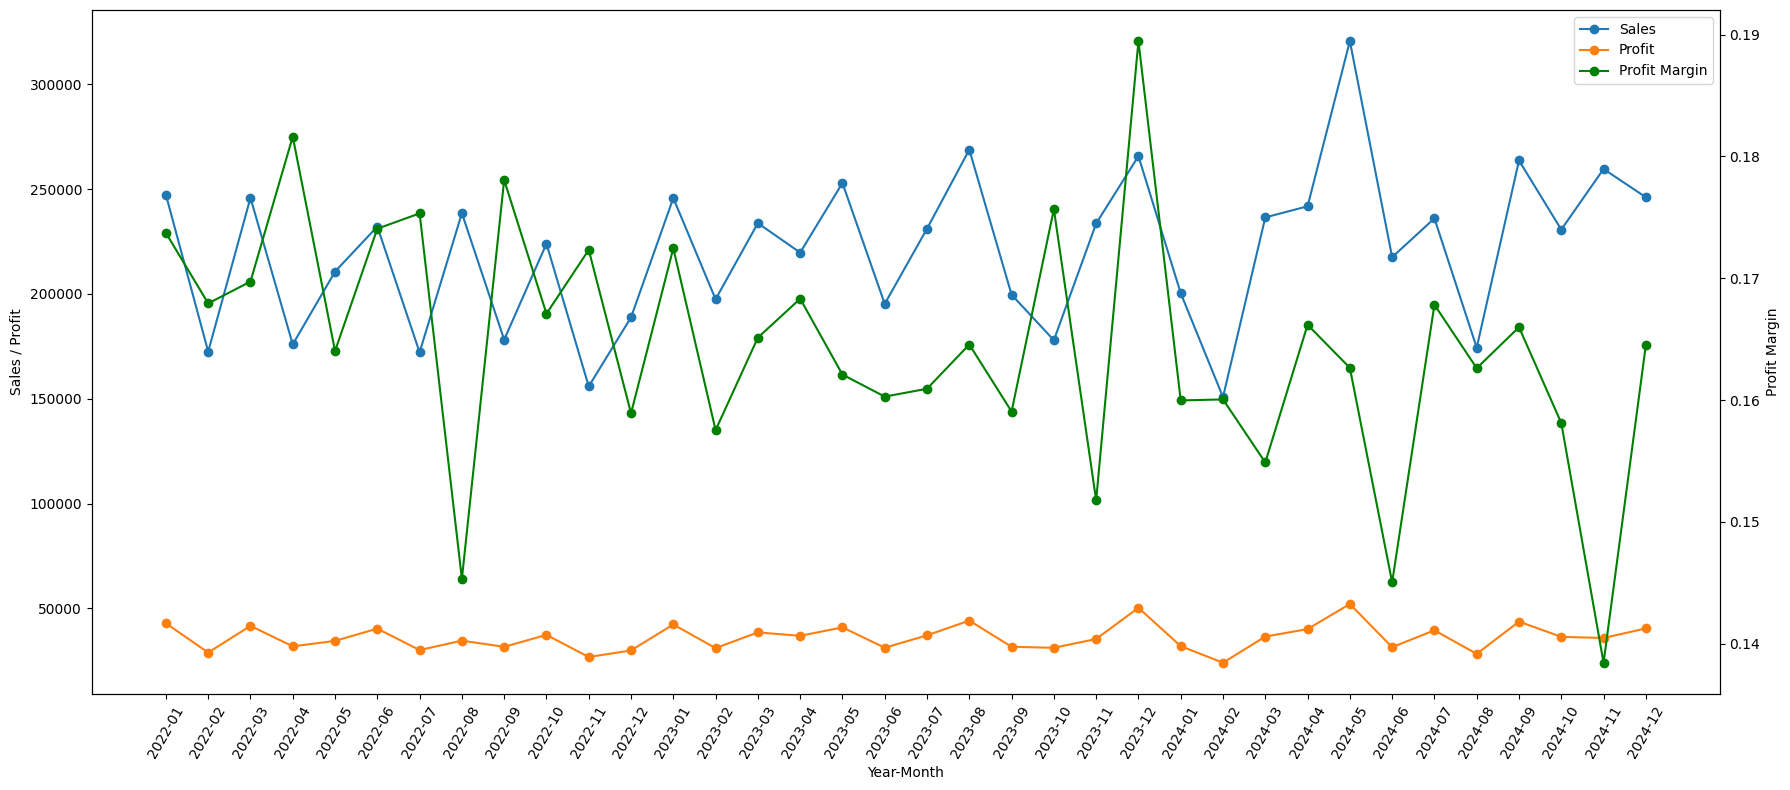

In [32]:
monthly_summary = df.groupby('Year-Month').agg({'Sales':'sum','Profit':'sum'})
monthly_summary['Profit Margin'] = monthly_summary['Profit']/monthly_summary['Sales']
monthly_summary = monthly_summary.reset_index()

fig, ax1 = plt.subplots(figsize=(18, 8))

x = monthly_summary['Year-Month'].astype(str)

ax1.plot(x, monthly_summary['Sales'], marker='o', label='Sales')
ax1.plot(x, monthly_summary['Profit'], marker='o', label='Profit')

ax2 = ax1.twinx()
ax2.plot(x, monthly_summary['Profit Margin'], marker='o', color='green', label='Profit Margin')

ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Sales / Profit')
ax2.set_ylabel('Profit Margin')

# 关键：让 ax1 的 x 轴标签旋转
ax1.tick_params(axis='x', labelrotation=60)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='best'
)

plt.tight_layout()
plt.show()


In [33]:
category_per_year = df.groupby(['Category','Year']).agg({'Sales':'sum','Profit':'sum'})
category_per_year['Profit Margin'] = category_per_year['Profit']/category_per_year['Sales']
# print(183525.620	/1034658.190)
# print(398492.689	/2257388.850)
category_per_year
category_per_year = category_per_year.reset_index()
category_per_year
# df['Category'].value_counts()

,Category,Year,Sales,Profit,Profit Margin
0,Accessories,2022,810911.830,135583.350,0.167199
1,Accessories,2023,924845.235,150454.215,0.162680
2,Accessories,2024,975524.835,154600.165,0.158479
3,Electronics,2022,1529353.410,262365.530,0.171553
4,Electronics,2023,1706749.610,287206.100,0.168277
5,Electronics,2024,1741514.460,277576.670,0.159388
6,Office,2022,101578.310,13481.890,0.132724
7,Office,2023,89908.050,13918.910,0.154813
8,Office,2024,60820.390,9130.630,0.150124


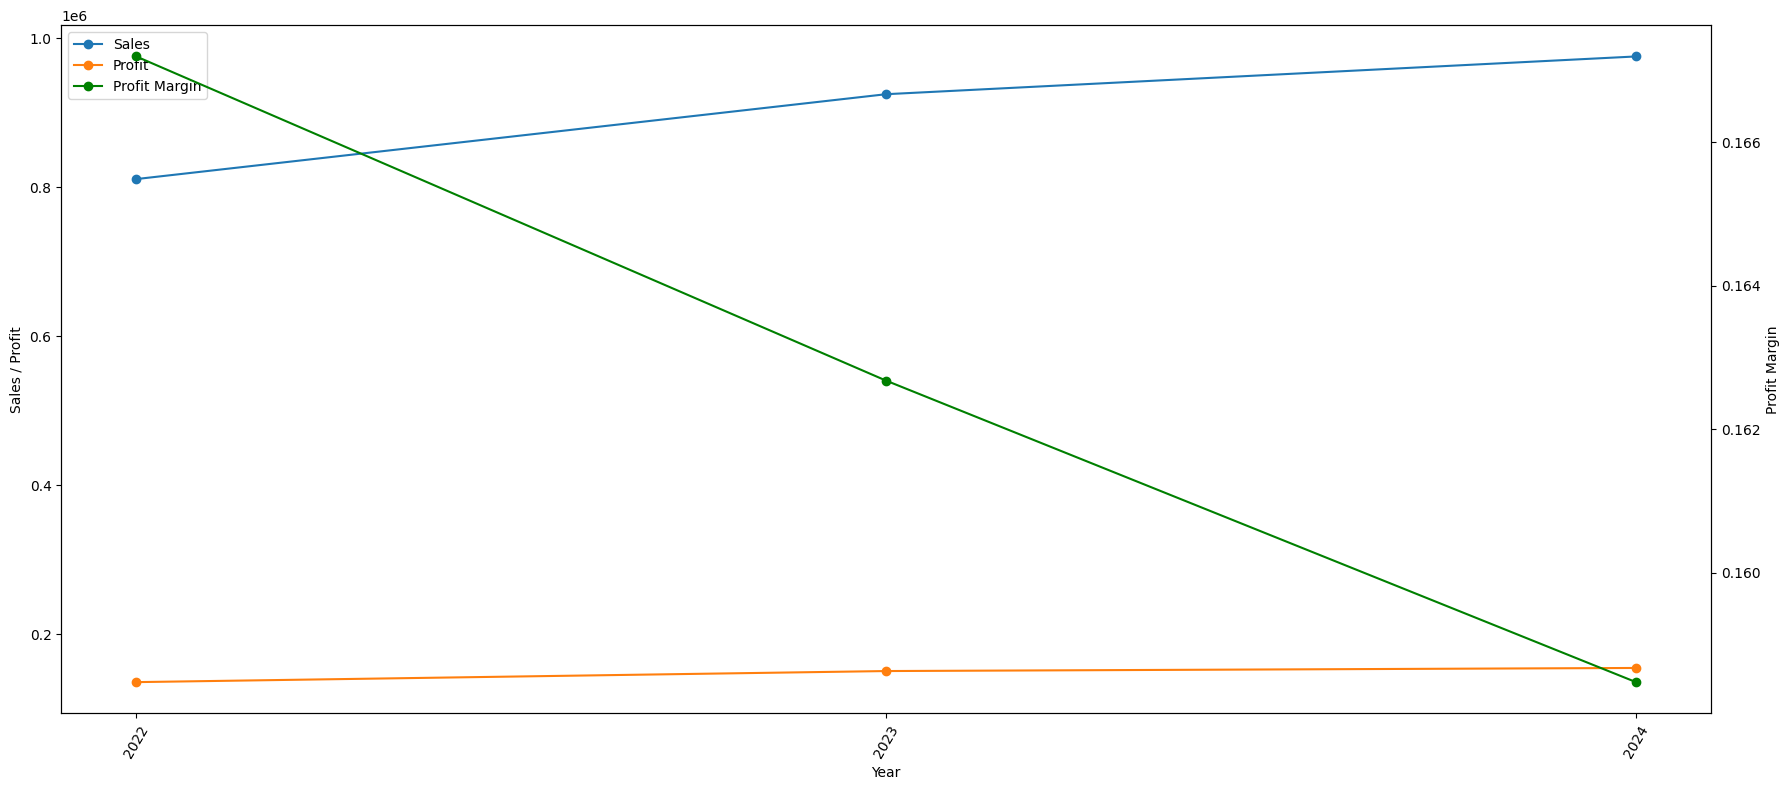

In [34]:
accessory_per_year = category_per_year.loc[category_per_year['Category'] == 'Accessories' ]
accessory_per_year

accessory_per_year

fig, ax1 = plt.subplots(figsize=(18, 8))

x = accessory_per_year['Year'].astype(str)

ax1.plot(x, accessory_per_year['Sales'], marker='o', label='Sales')
ax1.plot(x, accessory_per_year['Profit'], marker='o', label='Profit')

ax2 = ax1.twinx()
ax2.plot(x, accessory_per_year['Profit Margin'], marker='o', color='green', label='Profit Margin')

ax1.set_xlabel('Year')
ax1.set_ylabel('Sales / Profit')
ax2.set_ylabel('Profit Margin')

# 关键：让 ax1 的 x 轴标签旋转
ax1.tick_params(axis='x', labelrotation=60)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='best'
)

plt.tight_layout()
plt.show()

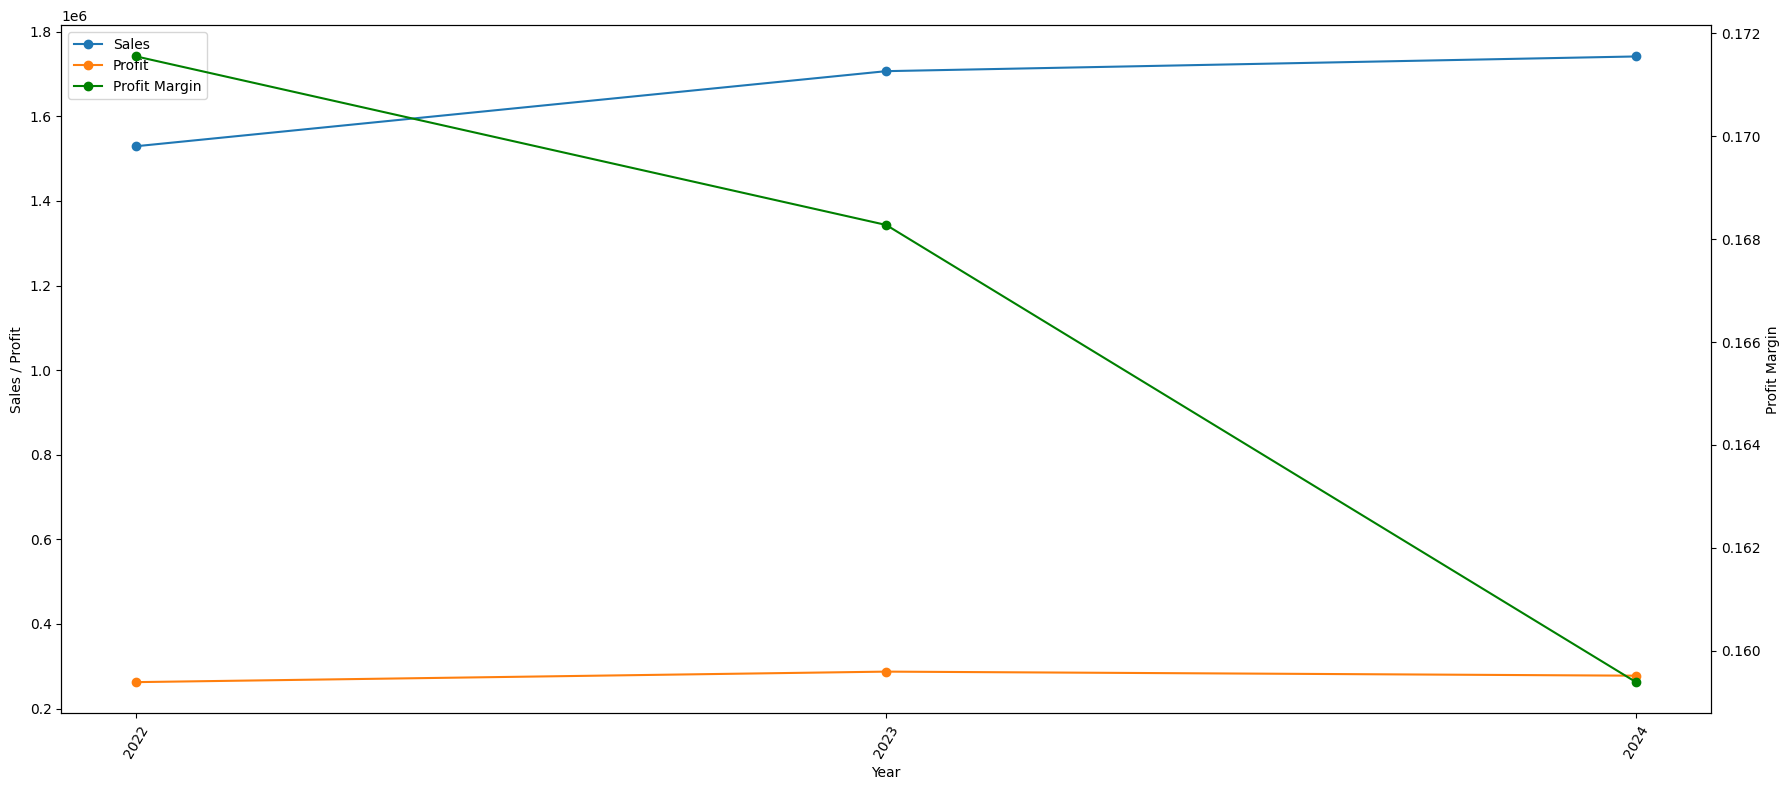

In [35]:
Electronics_per_year = category_per_year.loc[category_per_year['Category'] == 'Electronics' ]
Electronics_per_year


fig, ax1 = plt.subplots(figsize=(18, 8))

x = Electronics_per_year['Year'].astype(str)

ax1.plot(x, Electronics_per_year['Sales'], marker='o', label='Sales')
ax1.plot(x, Electronics_per_year['Profit'], marker='o', label='Profit')

ax2 = ax1.twinx()
ax2.plot(x, Electronics_per_year['Profit Margin'], marker='o', color='green', label='Profit Margin')

ax1.set_xlabel('Year')
ax1.set_ylabel('Sales / Profit')
ax2.set_ylabel('Profit Margin')

# 关键：让 ax1 的 x 轴标签旋转
ax1.tick_params(axis='x', labelrotation=60)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='best'
)

plt.tight_layout()
plt.show()

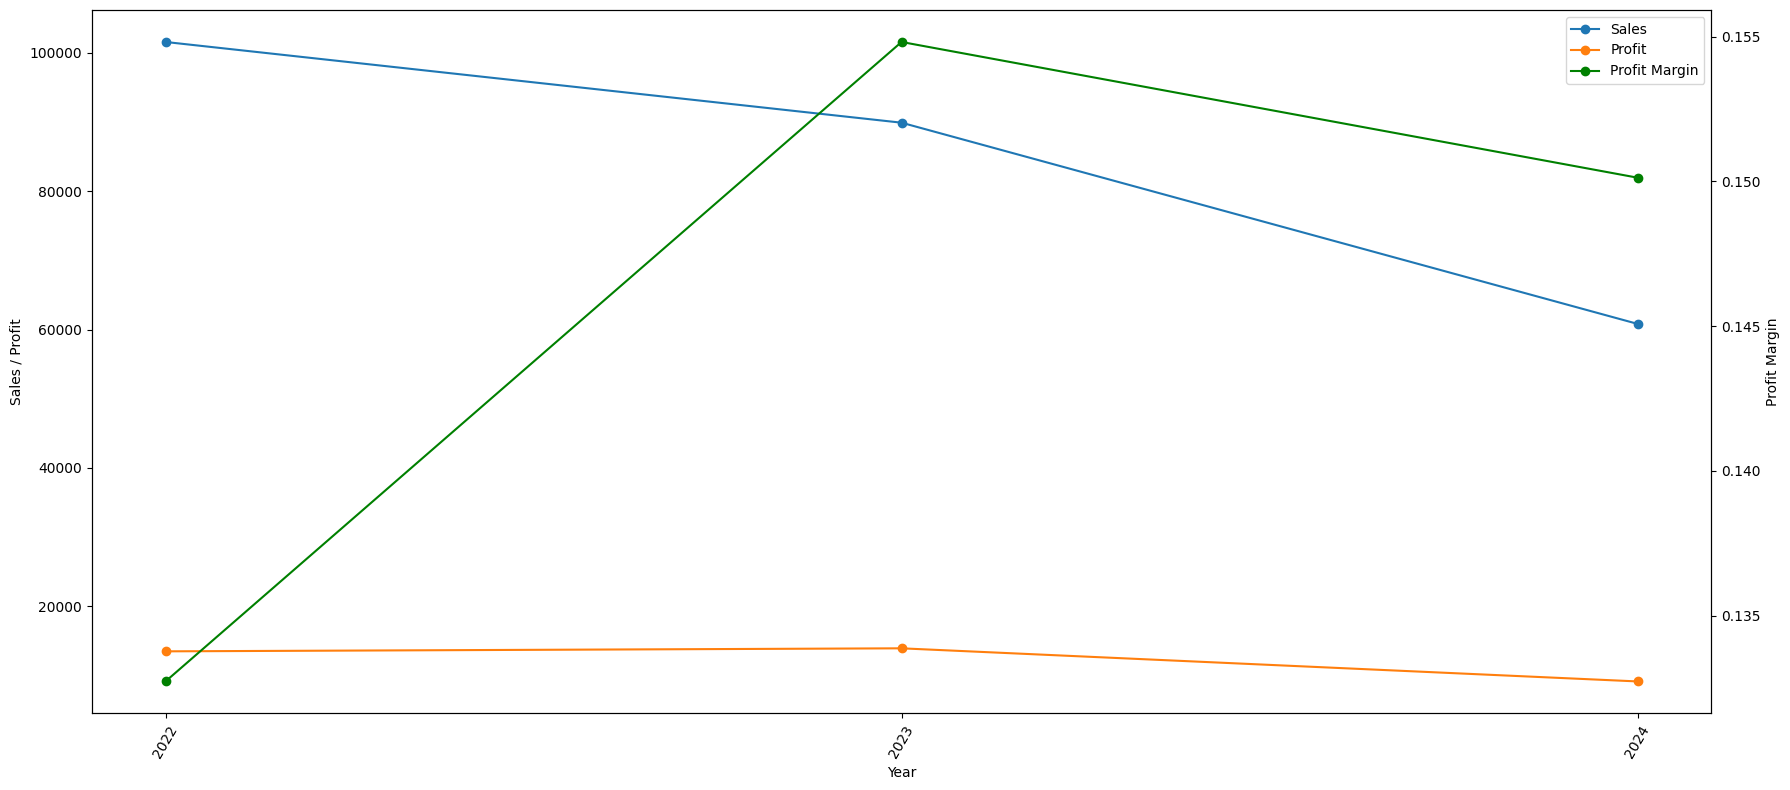

In [36]:
Office_per_year = category_per_year.loc[category_per_year['Category'] == 'Office' ]
Office_per_year


fig, ax1 = plt.subplots(figsize=(18, 8))

x = Office_per_year['Year'].astype(str)

ax1.plot(x, Office_per_year['Sales'], marker='o', label='Sales')
ax1.plot(x, Office_per_year['Profit'], marker='o', label='Profit')

ax2 = ax1.twinx()
ax2.plot(x, Office_per_year['Profit Margin'], marker='o', color='green', label='Profit Margin')

ax1.set_xlabel('Year')
ax1.set_ylabel('Sales / Profit')
ax2.set_ylabel('Profit Margin')

# 关键：让 ax1 的 x 轴标签旋转
ax1.tick_params(axis='x', labelrotation=60)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='best'
)

plt.tight_layout()
plt.show()

In [37]:
sales_each_region = df.groupby(['Region','Year']).agg({'Sales':'sum'}).reset_index()
sales_each_region

plot_data = sales_each_region.pivot(
    index='Year',
    columns='Region',
    values='Sales'
)
sales_each_region = plot_data
plot_data



Region,East,North,South,West
Year,,,,
2022,637508.790,610328.805,608748.110,585257.845
2023,699725.395,633366.815,657786.080,730624.605
2024,699989.400,609785.345,674289.545,793795.395


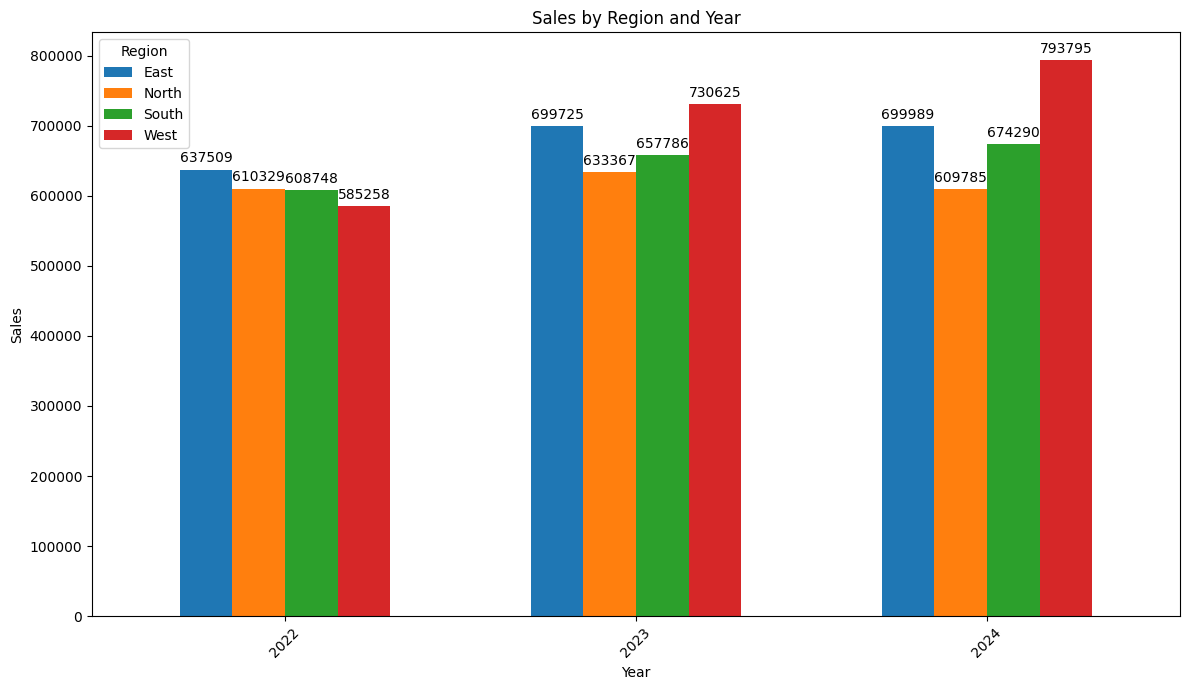

In [38]:
ax = plot_data.plot(
    kind='bar',
    figsize=(12, 7),
    width=0.6
)

# 给每根柱子加数字
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        label_type='edge',
        padding=3
    )
    
ax.set_title('Sales by Region and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Sales')
ax.legend(title='Region')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
annual_summary


pct_each_region = sales_each_region.reset_index()
pct_each_region.columns.name = None
pct_each_region['East pct'] =  pct_each_region['East']/annual_summary['Sales']
pct_each_region['North pct'] =  pct_each_region['North']/annual_summary['Sales']
pct_each_region['South pct'] =  pct_each_region['South']/annual_summary['Sales']
pct_each_region['West pct'] =  pct_each_region['West']/annual_summary['Sales']
pct_each_region = pct_each_region[['Year','East pct','North pct','South pct','West pct']]
pct_each_region
# pct_each_region.info()

,Year,East pct,North pct,South pct,West pct
0,2022,0.261077,0.249946,0.249299,0.239679
1,2023,0.257110,0.232727,0.241700,0.268464
2,2024,0.251989,0.219516,0.242737,0.285758


In [40]:
annual_summary

,Year,Sales,Sales Growth Rate,Profit,Profit Growth Rate,Profit Margin,Profit Margin Change
0,2022,2441843.550,NaN,411430.770,NaN,0.168492,NaN
1,2023,2721502.895,0.114528,451579.225,0.097583,0.165930,-0.002562
2,2024,2777859.685,0.020708,441307.465,-0.022746,0.158866,-0.007064


In [41]:
profit_each_region = df.groupby(['Region','Year']).agg({'Profit':'sum'}).reset_index()
plot_data = profit_each_region.pivot(index = 'Year',columns = 'Region',values = 'Profit')
profit_each_region = plot_data
plot_data

Region,East,North,South,West
Year,,,,
2022,110437.760,96847.875,107030.525,97114.610
2023,114168.365,105750.360,111848.685,119811.815
2024,108850.450,103591.900,99212.935,129652.180


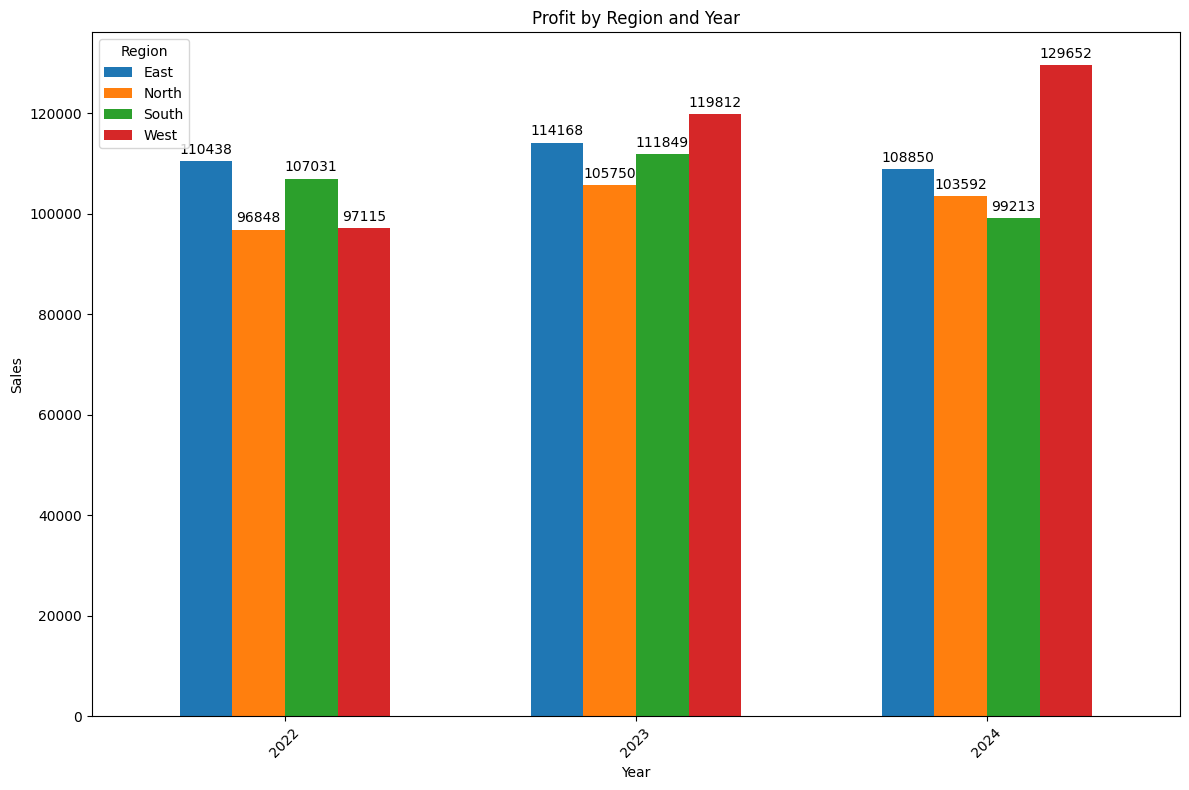

In [42]:
ax = plot_data.plot(
    kind='bar',
    figsize=(12, 8),
    width=0.6
)

# 给每根柱子加数字
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        label_type='edge',
        padding=3
    )
    
ax.set_title('Profit by Region and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Sales')
ax.legend(title='Region')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
profit_each_region
profit_each_region.columns.name = None
profit_each_region


,East,North,South,West
Year,,,,
2022,110437.760,96847.875,107030.525,97114.610
2023,114168.365,105750.360,111848.685,119811.815
2024,108850.450,103591.900,99212.935,129652.180


In [44]:
sales_each_region
sales_each_region.columns.name = None
sales_each_region

,East,North,South,West
Year,,,,
2022,637508.790,610328.805,608748.110,585257.845
2023,699725.395,633366.815,657786.080,730624.605
2024,699989.400,609785.345,674289.545,793795.395


In [45]:
profit_margin_each_region = profit_each_region / sales_each_region
profit_margin_each_region

,East,North,South,West
Year,,,,
2022,0.173233,0.158681,0.175821,0.165935
2023,0.163162,0.166965,0.170038,0.163985
2024,0.155503,0.169883,0.147137,0.163332


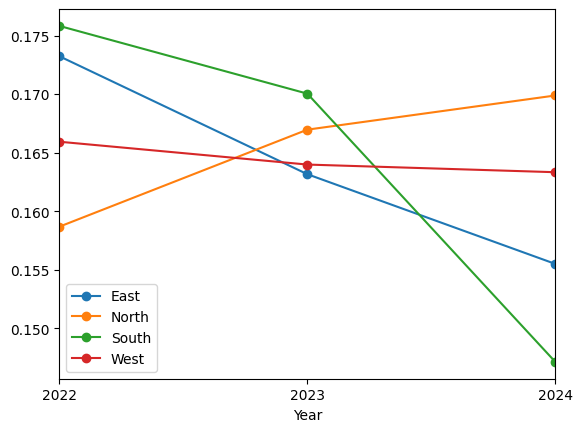

In [46]:
profit_margin_each_region.plot(kind = 'line',marker = 'o',y = ['East','North','South','West'])
plt.show()

In [47]:
df

,Year,Quarter,Year-Month,Order Date,Region,Category,Product Name,Unit Price,Quantity,Sales,Profit,Profit Margin
0,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Mouse,1158.280000,3,3474.840,565.000,0.162597
1,2022,2022Q1,2022-01,2022-01-01,South,Accessories,Monitor,162.031250,8,1296.250,273.970,0.211356
2,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Keyboard,1062.100000,6,6372.600,570.750,0.089563
3,2022,2022Q1,2022-01,2022-01-02,North,Accessories,Mouse,825.098750,4,3300.395,180.225,0.054607
4,2022,2022Q1,2022-01,2022-01-03,North,Electronics,Camera,389.022857,7,2723.160,638.260,0.234382
...,...,...,...,...,...,...,...,...,...,...,...,...
2829,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,394.008333,12,4728.100,1278.580,0.270422
2830,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,950.028889,9,8550.260,1970.980,0.230517
2831,2024,2024Q4,2024-12,2024-12-29,South,Accessories,Monitor,834.101667,6,5004.610,1197.360,0.239251
2832,2024,2024Q4,2024-12,2024-12-30,North,Electronics,Camera,379.060000,1,379.060,39.410,0.103968


In [48]:
overall_sales_each_product = df.groupby('Product Name').agg({'Sales':'sum','Profit':'sum'}).reset_index()
overall_sales_each_product['Profit Margin'] = overall_sales_each_product['Profit'] / overall_sales_each_product['Sales']
overall_sales_each_product
# overall_sales_each_product.loc[overall_sales_each_product['Sales'].idxmax()]
# overall_sales_each_product.loc[overall_sales_each_product['Sales'].idxmin()]

# overall_sales_each_product.loc[overall_sales_each_product['Profit'].idxmax()]
# overall_sales_each_product.loc[overall_sales_each_product['Profit'].idxmin()]

# overall_sales_each_product.loc[overall_sales_each_product['Profit Margin'].idxmax()]
# overall_sales_each_product.loc[overall_sales_each_product['Profit Margin'].idxmin()]
overall_sales_each_product.sort_values(by = 'Sales')


,Product Name,Sales,Profit,Profit Margin
6,Printer,252306.750,36531.43,0.144790
2,Keyboard,551225.655,86887.87,0.157627
1,Headphones,573377.880,96090.35,0.167586
5,Mouse,627848.525,103792.13,0.165314
9,Tablet,794478.480,125450.90,0.157903
8,Smartwatch,841254.900,132862.17,0.157933
4,Monitor,958829.840,153867.38,0.160474
0,Camera,1020240.540,168956.93,0.165605
3,Laptop,1125867.960,200415.28,0.178010
7,Smartphone,1195775.600,199463.02,0.166806


In [49]:
overall_sales_each_product.sort_values(by = 'Profit')


,Product Name,Sales,Profit,Profit Margin
6,Printer,252306.750,36531.43,0.144790
2,Keyboard,551225.655,86887.87,0.157627
1,Headphones,573377.880,96090.35,0.167586
5,Mouse,627848.525,103792.13,0.165314
9,Tablet,794478.480,125450.90,0.157903
8,Smartwatch,841254.900,132862.17,0.157933
4,Monitor,958829.840,153867.38,0.160474
0,Camera,1020240.540,168956.93,0.165605
7,Smartphone,1195775.600,199463.02,0.166806
3,Laptop,1125867.960,200415.28,0.178010


In [50]:
sales_each_product_per_year = df.groupby(['Year','Product Name']).agg({'Sales':'sum','Profit':'sum'}).reset_index()
sales_each_product_per_year['Profit Margin'] = sales_each_product_per_year['Profit']/sales_each_product_per_year['Sales']
sales_each_product_per_year


,Year,Product Name,Sales,Profit,Profit Margin
0,2022,Camera,316997.290,52578.710,0.165865
1,2022,Headphones,175632.850,31267.310,0.178027
2,2022,Keyboard,159603.905,26548.755,0.166342
3,2022,Laptop,286293.250,54317.580,0.189727
4,2022,Monitor,272578.740,42433.790,0.155675
5,2022,Mouse,203096.335,35333.495,0.173974
6,2022,Printer,101578.310,13481.890,0.132724
7,2022,Smartphone,384270.730,64962.910,0.169055
8,2022,Smartwatch,272563.680,44135.470,0.161927
9,2022,Tablet,269228.460,46370.860,0.172236


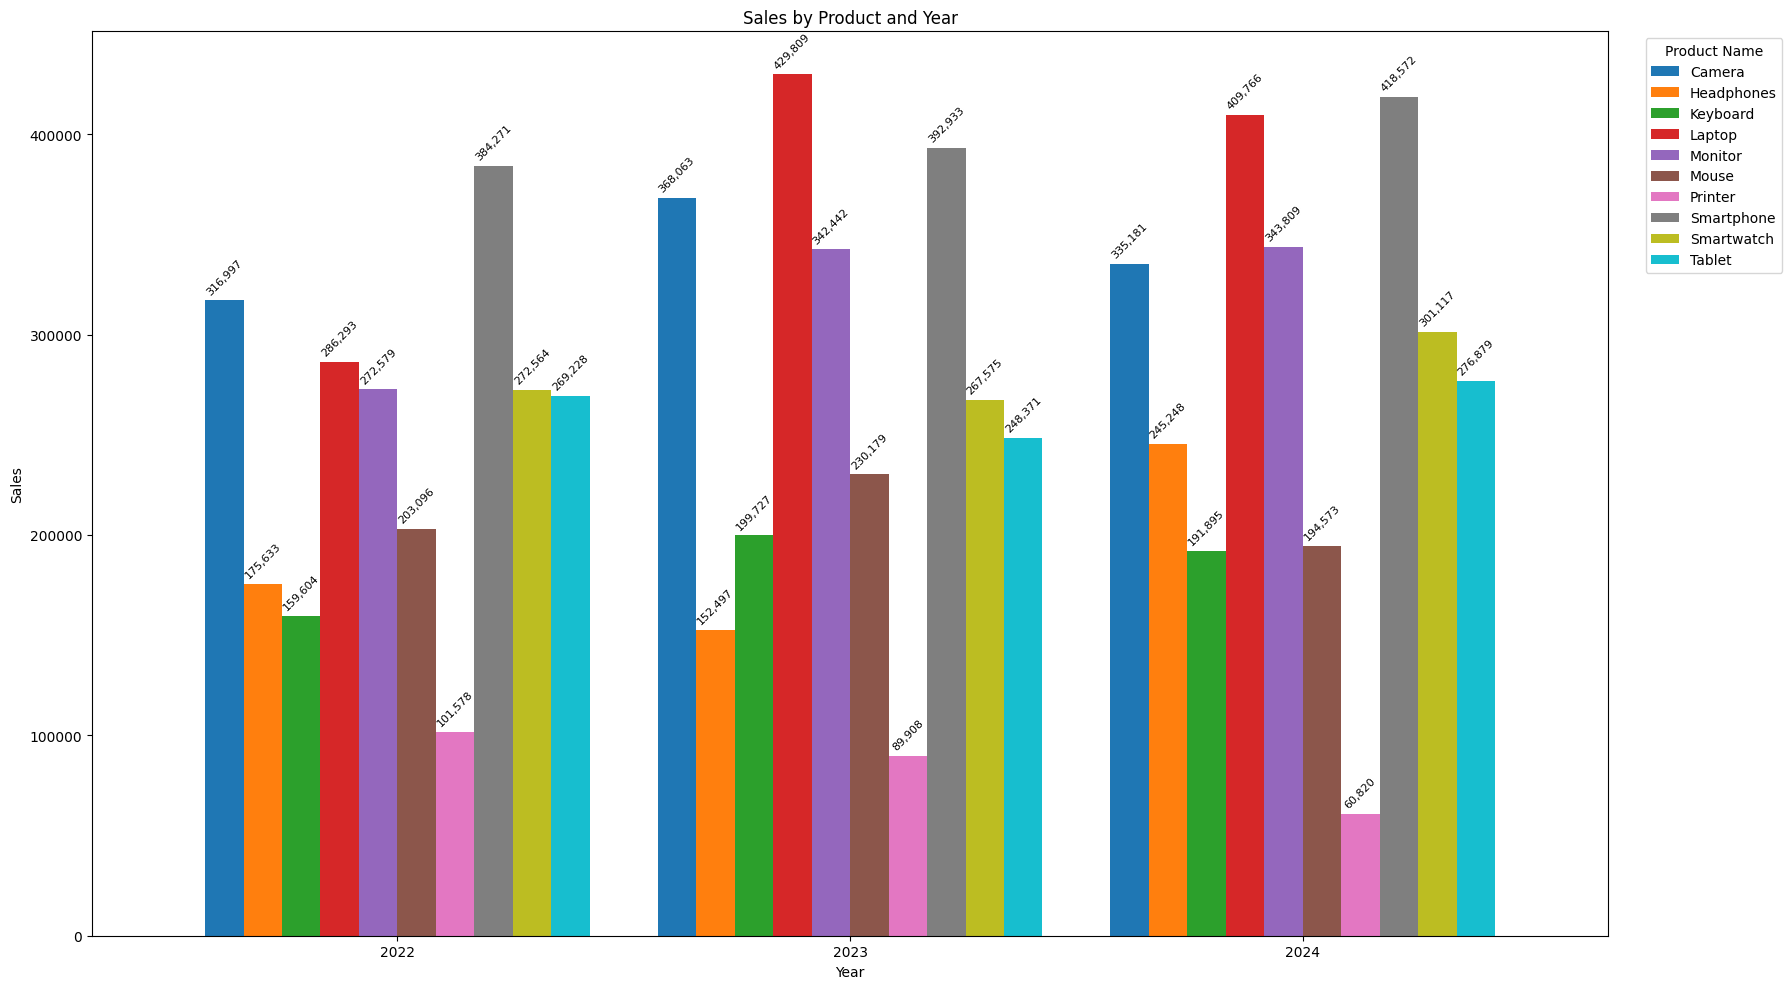

In [51]:
plot_data = sales_each_product_per_year.pivot(
    index='Year',
    columns='Product Name',
    values='Sales'
)

plot_data

ax = plot_data.plot(
    kind='bar',
    figsize=(18, 10),
    width=0.85
)

ax.set_title('Sales by Product and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Sales')
ax.legend(title='Product Name', bbox_to_anchor=(1.02, 1), loc='upper left')

# 显示每根柱子的数字
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        padding=3,
        fontsize=8,
        rotation=45
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

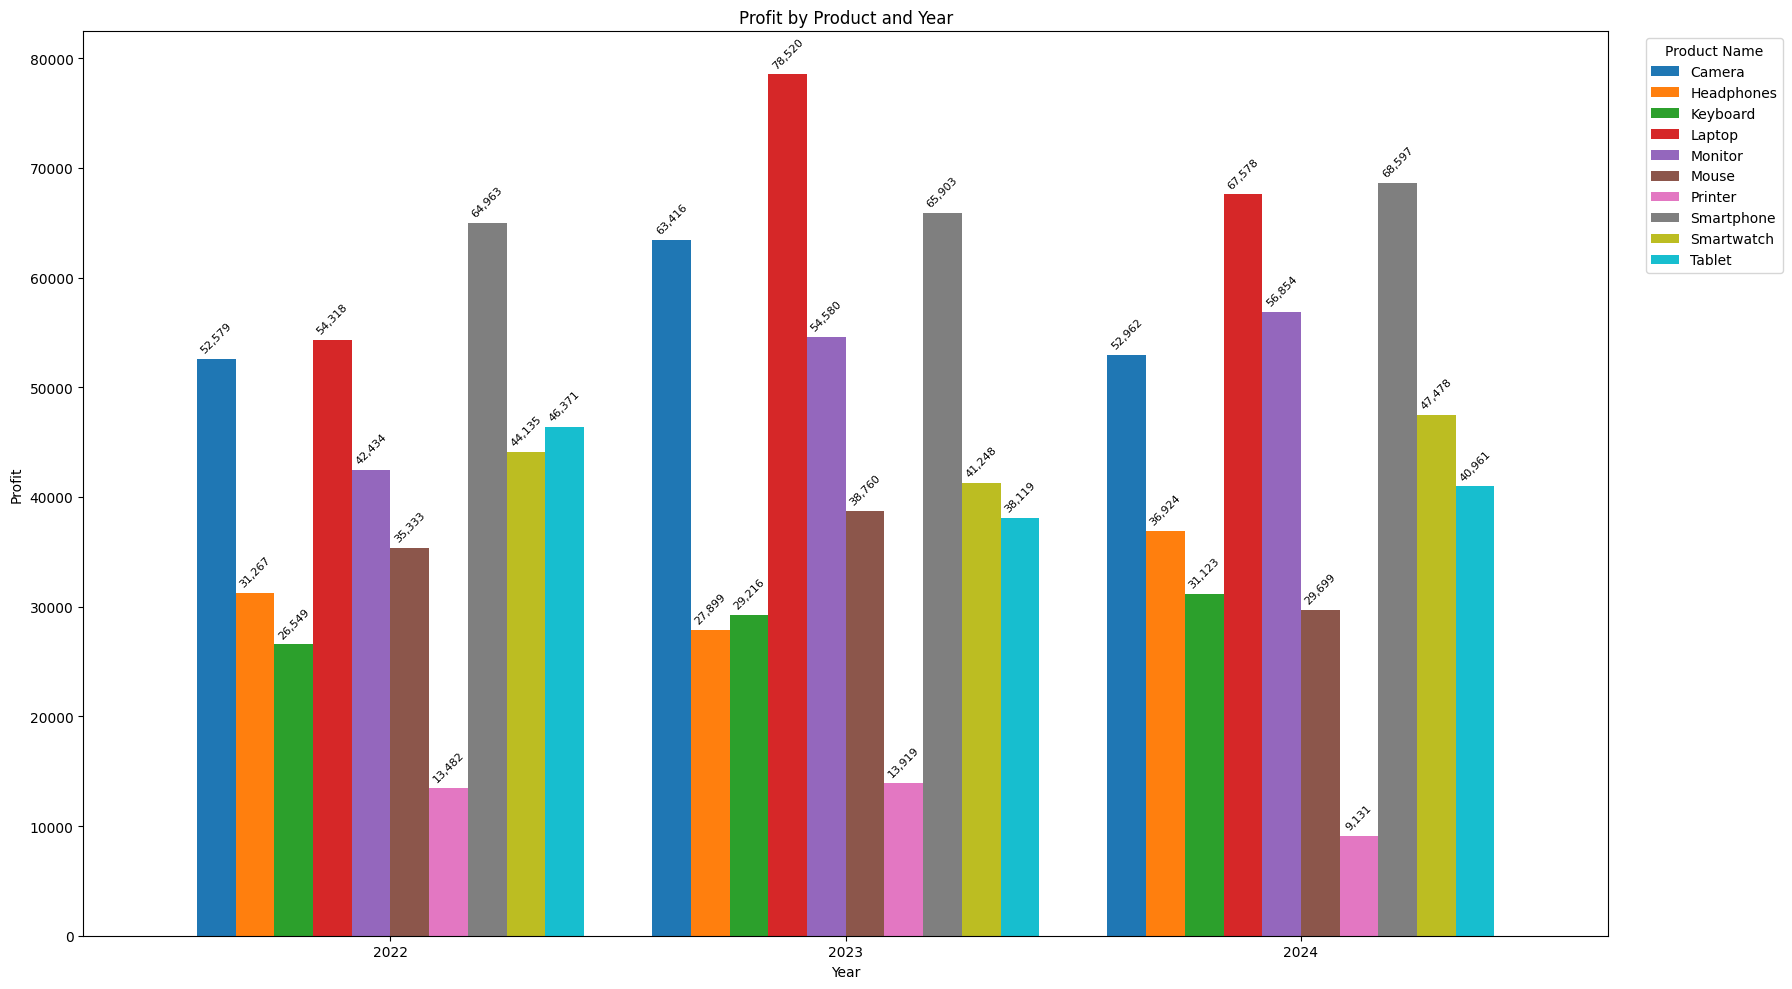

In [52]:
plot_data = sales_each_product_per_year.pivot(
    index='Year',
    columns='Product Name',
    values='Profit'
)

plot_data

ax = plot_data.plot(
    kind='bar',
    figsize=(18, 10),
    width=0.85
)

ax.set_title('Profit by Product and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Profit')
ax.legend(title='Product Name', bbox_to_anchor=(1.02, 1), loc='upper left')

# 显示每根柱子的数字
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        padding=3,
        fontsize=8,
        rotation=45
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

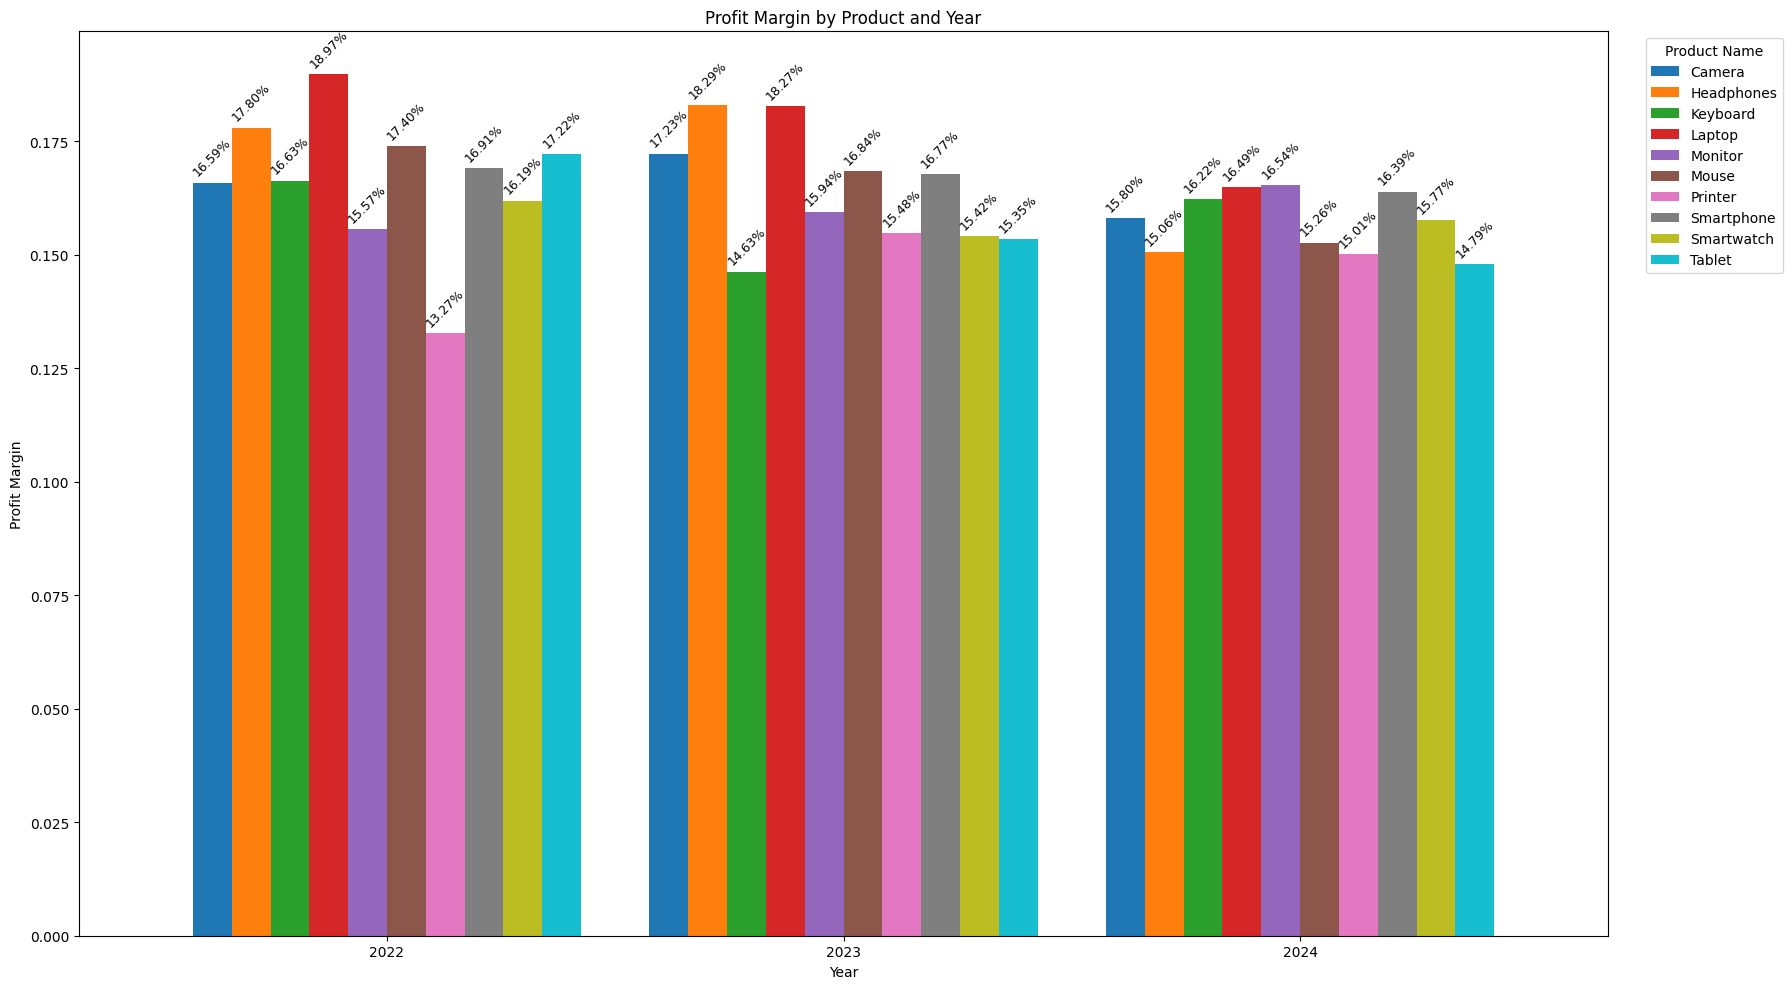

In [53]:
plot_data = sales_each_product_per_year.pivot(
    index='Year',
    columns='Product Name',
    values='Profit Margin'
)

plot_data

ax = plot_data.plot(
    kind='bar',
    figsize=(18, 10),
    width=0.85
)

ax.set_title('Profit Margin by Product and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Profit Margin')
ax.legend(title='Product Name', bbox_to_anchor=(1.02, 1), loc='upper left')

# 显示每根柱子的数字
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:.2%}' for v in container.datavalues],
        padding=3,
        fontsize=9,
        rotation=45
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [54]:
all_sales = df['Sales'].sum()
all_sales

sales_each_region = df.groupby('Region').agg({'Sales':'sum'}).reset_index()
sales_each_region['Sales pct'] = sales_each_region['Sales']/all_sales
sales_each_region
# plot_data = sales_each_region.pivot(
#     index='Year',
#     columns='Region',
#     values='Sales'
# )
# sales_each_region = plot_data
# sales_each_region.columns.name = None
# sales_each_region

,Region,Sales,Sales pct
0,East,2037223.585,0.256538
1,North,1853480.965,0.233400
2,South,1940823.735,0.244399
3,West,2109677.845,0.265662


In [55]:
all_sales

np.float64(7941206.13)

In [56]:
all_profit = df['Profit'].sum()
all_profit

profit_each_region = df.groupby('Region').agg({'Profit':'sum'}).reset_index()
profit_each_region['Profit pct'] = profit_each_region['Profit']/all_profit
profit_each_region

,Region,Profit,Profit pct
0,East,333456.575,0.255656
1,North,306190.135,0.234751
2,South,318092.145,0.243876
3,West,346578.605,0.265716


In [57]:
profit_each_region_per_year = df.groupby(['Year','Region']).agg({'Profit':'sum'}).reset_index()
profit_each_region_per_year = profit_each_region_per_year.pivot(index = 'Year',columns = 'Region',values = 'Profit')
profit_each_region_per_year.columns.name = None
profit_each_region_per_year = profit_each_region_per_year.reset_index()
profit_each_region_per_year

,Year,East,North,South,West
0,2022,110437.760,96847.875,107030.525,97114.610
1,2023,114168.365,105750.360,111848.685,119811.815
2,2024,108850.450,103591.900,99212.935,129652.180


In [58]:
annual_summary

pct_profit_region = profit_each_region_per_year
pct_profit_region['East pct'] = profit_each_region_per_year['East'] / annual_summary['Profit']
pct_profit_region['North pct'] = profit_each_region_per_year['North'] / annual_summary['Profit']
pct_profit_region['South pct'] = profit_each_region_per_year['South'] / annual_summary['Profit']
pct_profit_region['West pct'] = profit_each_region_per_year['West'] / annual_summary['Profit']

pct_profit_region

,Year,East,North,South,West,East pct,North pct,South pct,West pct
0,2022,110437.760,96847.875,107030.525,97114.610,0.268424,0.235393,0.260142,0.236041
1,2023,114168.365,105750.360,111848.685,119811.815,0.252820,0.234179,0.247683,0.265317
2,2024,108850.450,103591.900,99212.935,129652.180,0.246654,0.234739,0.224816,0.293791


In [59]:
df['Category'].value_counts()

Category
Electronics    1596
Accessories    1143
Office           95
Name: count, dtype: int64

In [60]:
df['Category'].value_counts()

Category
Electronics    1596
Accessories    1143
Office           95
Name: count, dtype: int64

In [61]:
df['Profit'].describe()

count    2834.000000
mean      460.239047
std       424.822875
min         6.000000
25%       149.970000
50%       333.695000
75%       636.752500
max      2696.520000
Name: Profit, dtype: float64

In [62]:
df.loc[df['Profit']>=635].describe()

,Order Date,Unit Price,Quantity,Sales,Profit,Profit Margin
count,713,713.000000,713.000000,713.000000,713.000000,713.000000
mean,2023-07-09 07:26:20.364656,800.887925,7.235624,5455.369712,1062.594158,0.207642
min,2022-01-03 00:00:00,201.034444,2.000000,2216.630000,635.320000,0.052368
25%,2022-10-15 00:00:00,620.118000,5.000000,3829.730000,763.140000,0.169469
50%,2023-07-23 00:00:00,825.075714,7.000000,4920.940000,964.430000,0.208986
75%,2024-04-11 00:00:00,988.090000,8.000000,6592.880000,1241.270000,0.252970
max,2024-12-29 00:00:00,1497.655000,18.000000,14221.300000,2696.520000,0.299948
std,NaN,242.715492,3.078654,2248.138819,385.185052,0.055816


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2834 entries, 0 to 2833
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Year           2834 non-null   period[Y-DEC] 
 1   Quarter        2834 non-null   period[Q-DEC] 
 2   Year-Month     2834 non-null   period[M]     
 3   Order Date     2834 non-null   datetime64[us]
 4   Region         2834 non-null   category      
 5   Category       2834 non-null   category      
 6   Product Name   2834 non-null   category      
 7   Unit Price     2834 non-null   float64       
 8   Quantity       2834 non-null   int64         
 9   Sales          2834 non-null   float64       
 10  Profit         2834 non-null   float64       
 11  Profit Margin  2834 non-null   float64       
dtypes: category(3), datetime64[us](1), float64(4), int64(1), period[M](1), period[Q-DEC](1), period[Y-DEC](1)
memory usage: 208.4 KB


In [64]:
outlier = outlier.reset_index(drop=True)
outlier

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2023-12-25,Mouse,Accessories,North,6,7146.65,1627.42
1,2024-06-29,Mouse,Accessories,West,9,7506.65,594.28
2,2022-02-19,Mouse,Accessories,West,6,5622.74,1382.67
3,2023-08-12,Mouse,Accessories,South,6,6228.01,1852.45
4,2022-07-26,Mouse,Accessories,East,8,6056.23,1631.71
...,...,...,...,...,...,...,...
202,2023-02-21,Laptop,Electronics,East,18,18451.26,5052.54
203,2023-03-25,Laptop,Electronics,South,18,11107.78,2865.52
204,2022-11-07,Laptop,Electronics,East,18,9721.08,2851.08
205,2024-06-30,Laptop,Electronics,West,12,12468.30,3658.14


In [65]:
outlier.describe()

,Order Date,Quantity,Sales,Profit
count,207,207.000000,207.000000,207.000000
mean,2023-07-07 15:11:18.260869,9.541063,9524.530169,2013.729826
min,2022-01-01 00:00:00,1.000000,3839.770000,448.620000
25%,2022-11-15 00:00:00,7.000000,6798.840000,1414.380000
50%,2023-07-08 00:00:00,9.000000,8240.650000,1777.320000
75%,2024-02-15 00:00:00,9.000000,10363.995000,2329.800000
max,2024-12-25 00:00:00,18.000000,30470.070000,5676.899000
std,NaN,3.872608,4173.384328,974.796701


In [66]:
#大订单,高额订单，高利润订单

outlier.groupby(['Region']).agg({'Quantity':'count','Sales':'sum','Profit':'sum'})

,Quantity,Sales,Profit
Region,,,
East,49,452910.260,97770.800
North,53,523797.345,108510.254
South,48,426418.490,90293.140
West,57,568451.650,120267.880


In [67]:
#

outlier.groupby(['Region','Product Name']).agg({'Quantity':'count','Sales':'sum','Profit':'sum'})

Quantity       Sales     Profit
Region Product Name                                 
East   Camera               5   40303.080  10634.010
       Headphones           3   21047.950   5496.710
       Keyboard             9   68585.450  13541.970
       Laptop               4   60586.100  10895.500
       Monitor              2   11609.030   3367.610
       Mouse                3   20728.160   3871.290
       Printer              3   22895.180   5000.390
       Smartphone           7  109533.280  24490.740
       Smartwatch           6   39942.550   9394.220
       Tablet               7   57679.480  11078.360
North  Camera               4   32794.030   7885.100
       Keyboard             6   31687.890   7335.230
       Laptop               8  125149.080  28025.880
       Monitor              7   59113.750  14370.270
       Mouse                6   45013.915   8384.495
       Printer              1    7264.700   1318.000
       Smartphone           4   69624.100   9486.380
       Smartwatch           7   55100.480  11186.230
       Tablet              10   98049.400  20518.669
South  Camera               4   34575.880   8532.750
       Headphones           3   25060.690   3937.400
       Keyboard             7   57344.510  11663.470
       Laptop               4   52795.350  11241.230
       Monitor              5   39353.860  10314.730
       Mouse                6   43388.670   8894.730
       Printer              3   19203.630   4508.360
       Smartphone           4   54638.910  12570.860
       Smartwatch           5   38643.870   9240.150
       Tablet               7   61413.120   9389.460
West   Camera               4   31761.150   8180.230
       Headphones           3   24242.680   5600.830
       Keyboard             7   53322.140  11016.010
       Laptop               7  119963.360  25942.480
       Monitor              9   75278.380  17531.790
       Mouse                6   40260.170   7574.340
       Printer              3   20039.730   4485.570
       Smartphone           8  131053.260  23506.460
       Smartwatch           8   59086.420  13546.660
       Tablet               2   13444.360   2883.510

In [68]:
outlier.groupby(['Product Name','Region']).agg({'Quantity':'count','Sales':'sum','Profit':'sum'})

Quantity       Sales     Profit
Product Name Region                                 
Camera       East           5   40303.080  10634.010
             North          4   32794.030   7885.100
             South          4   34575.880   8532.750
             West           4   31761.150   8180.230
Headphones   East           3   21047.950   5496.710
             South          3   25060.690   3937.400
             West           3   24242.680   5600.830
Keyboard     East           9   68585.450  13541.970
             North          6   31687.890   7335.230
             South          7   57344.510  11663.470
             West           7   53322.140  11016.010
Laptop       East           4   60586.100  10895.500
             North          8  125149.080  28025.880
             South          4   52795.350  11241.230
             West           7  119963.360  25942.480
Monitor      East           2   11609.030   3367.610
             North          7   59113.750  14370.270
             South          5   39353.860  10314.730
             West           9   75278.380  17531.790
Mouse        East           3   20728.160   3871.290
             North          6   45013.915   8384.495
             South          6   43388.670   8894.730
             West           6   40260.170   7574.340
Printer      East           3   22895.180   5000.390
             North          1    7264.700   1318.000
             South          3   19203.630   4508.360
             West           3   20039.730   4485.570
Smartphone   East           7  109533.280  24490.740
             North          4   69624.100   9486.380
             South          4   54638.910  12570.860
             West           8  131053.260  23506.460
Smartwatch   East           6   39942.550   9394.220
             North          7   55100.480  11186.230
             South          5   38643.870   9240.150
             West           8   59086.420  13546.660
Tablet       East           7   57679.480  11078.360
             North         10   98049.400  20518.669
             South          7   61413.120   9389.460
             West           2   13444.360   2883.510

In [69]:
df

,Year,Quarter,Year-Month,Order Date,Region,Category,Product Name,Unit Price,Quantity,Sales,Profit,Profit Margin
0,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Mouse,1158.280000,3,3474.840,565.000,0.162597
1,2022,2022Q1,2022-01,2022-01-01,South,Accessories,Monitor,162.031250,8,1296.250,273.970,0.211356
2,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Keyboard,1062.100000,6,6372.600,570.750,0.089563
3,2022,2022Q1,2022-01,2022-01-02,North,Accessories,Mouse,825.098750,4,3300.395,180.225,0.054607
4,2022,2022Q1,2022-01,2022-01-03,North,Electronics,Camera,389.022857,7,2723.160,638.260,0.234382
...,...,...,...,...,...,...,...,...,...,...,...,...
2829,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,394.008333,12,4728.100,1278.580,0.270422
2830,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,950.028889,9,8550.260,1970.980,0.230517
2831,2024,2024Q4,2024-12,2024-12-29,South,Accessories,Monitor,834.101667,6,5004.610,1197.360,0.239251
2832,2024,2024Q4,2024-12,2024-12-30,North,Electronics,Camera,379.060000,1,379.060,39.410,0.103968


In [70]:
all_data

# 添加 年，年-月，季度 三个新列，并重新排列顺序
all_data['Unit Price'] = all_data['Sales']/all_data['Quantity']
all_data['Profit Margin'] = all_data['Profit']/all_data['Sales']
all_data.head()

all_data['Year'] = all_data['Order Date'].dt.to_period('Y')
all_data['Year-Month'] = all_data['Order Date'].dt.to_period('M')
all_data['Quarter'] = all_data['Order Date'].dt.to_period('Q')
all_data['Product Name'] = all_data['Product Name'].astype('category')

# df.head()

all_data = all_data[['Year','Quarter','Year-Month','Order Date','Region','Category','Product Name','Unit Price','Quantity','Sales','Profit'	,'Profit Margin']]
all_data = all_data.sort_values(by=['Year','Quarter','Year-Month','Order Date']).reset_index(drop = True)
all_data

,Year,Quarter,Year-Month,Order Date,Region,Category,Product Name,Unit Price,Quantity,Sales,Profit,Profit Margin
0,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Mouse,1158.280000,3,3474.840,565.000,0.162597
1,2022,2022Q1,2022-01,2022-01-01,South,Accessories,Monitor,162.031250,8,1296.250,273.970,0.211356
2,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Keyboard,1062.100000,6,6372.600,570.750,0.089563
3,2022,2022Q1,2022-01,2022-01-01,North,Electronics,Tablet,1026.095556,9,9234.860,2523.670,0.273276
4,2022,2022Q1,2022-01,2022-01-02,North,Accessories,Mouse,825.098750,4,3300.395,180.225,0.054607
...,...,...,...,...,...,...,...,...,...,...,...,...
3036,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,394.008333,12,4728.100,1278.580,0.270422
3037,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,950.028889,9,8550.260,1970.980,0.230517
3038,2024,2024Q4,2024-12,2024-12-29,South,Accessories,Monitor,834.101667,6,5004.610,1197.360,0.239251
3039,2024,2024Q4,2024-12,2024-12-30,North,Electronics,Camera,379.060000,1,379.060,39.410,0.103968


In [71]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3041 entries, 0 to 3040
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Year           3041 non-null   period[Y-DEC] 
 1   Quarter        3041 non-null   period[Q-DEC] 
 2   Year-Month     3041 non-null   period[M]     
 3   Order Date     3041 non-null   datetime64[us]
 4   Region         3041 non-null   category      
 5   Category       3041 non-null   category      
 6   Product Name   3041 non-null   category      
 7   Unit Price     3041 non-null   float64       
 8   Quantity       3041 non-null   int64         
 9   Sales          3041 non-null   float64       
 10  Profit         3041 non-null   float64       
 11  Profit Margin  3041 non-null   float64       
dtypes: category(3), datetime64[us](1), float64(4), int64(1), period[M](1), period[Q-DEC](1), period[Y-DEC](1)
memory usage: 223.3 KB


In [72]:
''' 
Year int
Quarter	int
Month int
day int
week day int
Region(4) cate
Category(3) cate
Product Name(10) cate
Unit Price float
Quantity int
Sales float
'''
all_data["Year"] = all_data["Order Date"].dt.year.astype('int32')
all_data["Quarter"] = all_data["Order Date"].dt.quarter.astype('int32')
all_data['Month'] = all_data['Order Date'].dt.month.astype('int32')
all_data['Day'] = all_data['Order Date'].dt.day.astype('int32')
all_data['Weekday'] = all_data['Order Date'].dt.dayofweek.astype('int32')
all_data['Quantity'] = all_data['Quantity'].astype('int32')

# all_data['Unit Price'] = all_data['Unit Price'].round(3)


data = all_data[['Year','Quarter','Month','Day','Weekday','Region','Category','Product Name','Quantity','Unit Price','Sales']]

# data.info()
# all_data['Day']
# # df['Weekday']
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3041 entries, 0 to 3040
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Year          3041 non-null   int32   
 1   Quarter       3041 non-null   int32   
 2   Month         3041 non-null   int32   
 3   Day           3041 non-null   int32   
 4   Weekday       3041 non-null   int32   
 5   Region        3041 non-null   category
 6   Category      3041 non-null   category
 7   Product Name  3041 non-null   category
 8   Quantity      3041 non-null   int32   
 9   Unit Price    3041 non-null   float64 
 10  Sales         3041 non-null   float64 
dtypes: category(3), float64(2), int32(6)
memory usage: 128.2 KB


In [73]:
bound = all_data["Profit"].quantile(0.75)
y = (all_data["Profit"] >= bound).astype(int)
y
X = data.copy()
X

cate_feature = ['Region', 'Category', 'Product Name']
num_feature = ['Year', 'Quarter', 'Month', 'Day', 'Weekday','Quantity', 'Unit Price', 'Sales']

preprocess = ColumnTransformer(transformers=[('cat',  OneHotEncoder(), cate_feature),('num', StandardScaler(),  num_feature)])

model = Pipeline(
    steps=[('preprocess', preprocess),
           ('clf', LogisticRegression(max_iter=4000, class_weight='balanced'))])

In [74]:
X_train, X_test, y_train, y_test = train_test_split(

    
    X,
    y,
    test_size=0.2,
    stratify=y,
    
    random_state=42)

# scores = cross_val_score(model,X_train,y_train,cv=5,scoring='accuracy')

# print(scores)
# print(scores.mean())

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [75]:
# y_pre = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [76]:
# for thresholds in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75]:
#     y_pred_new = (y_proba >= thresholds).astype(int)
#     print("Threshold:", thresholds)
#     print(classification_report(y_test, y_pred_new))
#     print(confusion_matrix(y_test, y_pred_new))
#     print("-" * 50)

# print(classification_report(y_test, y_pre))
thresholds = 0.7

y_pre_new = (y_prob >= thresholds).astype(int)

print(classification_report(y_test, y_pre_new))
print(confusion_matrix(y_test, y_pre_new))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       457
           1       0.76      0.78      0.77       152

    accuracy                           0.88       609
   macro avg       0.84      0.85      0.85       609
weighted avg       0.88      0.88      0.88       609

[[420  37]
 [ 34 118]]


In [77]:
print(confusion_matrix(y_test, y_pre_new))

[[420  37]
 [ 34 118]]


In [86]:

roc_auc = roc_auc_score(y_test, y_prob)
print("roc_auc:", roc_auc)
pr_auc = average_precision_score(y_test, y_prob)

print('pr_auc', pr_auc)

roc_auc: 0.9425169872163999
pr_auc 0.8025305709722906


In [79]:
pr_auc = average_precision_score(y_test, y_prob)

print('pr_auc', pr_auc)

pr_auc 0.8025305709722906


In [80]:

result = X_test.copy()
result['true'] = y_test.values
result["prob"] = y_prob

# top100 = result.sort_values('prob', ascending=False).head(10)

# precision100 = top100["true"].mean()
for k in [10, 25, 50, 100, 150]:
    topK = result.sort_values("prob", ascending=False).head(k)
    print(f"Precision@{k}:", topK['true'].mean())

# print("Precision@100:", precision100)

Precision@10: 1.0
Precision@25: 0.88
Precision@50: 0.9
Precision@100: 0.75
Precision@150: 0.7533333333333333


In [81]:
featureName = model.named_steps['preprocess'].get_feature_names_out()
coeff = model.named_steps["clf"].coef_[0]

coeff_df = pd.DataFrame({'feature': featureName,'coef': coeff}).sort_values('coef', ascending=False)

coeff_df.head(50)

,feature,coef
24,num__Sales,3.040846
23,num__Unit Price,0.398312
18,num__Quarter,0.317746
12,cat__Product Name_Mouse,0.187502
8,cat__Product Name_Headphones,0.157665
7,cat__Product Name_Camera,0.141481
22,num__Quantity,0.127771
14,cat__Product Name_Smartphone,0.122924
1,cat__Region_North,0.065596
5,cat__Category_Electronics,0.056587


In [82]:
coeff_df[coeff_df["feature"].str.contains("Region")]

,feature,coef
1,cat__Region_North,0.065596
0,cat__Region_East,-0.087486
2,cat__Region_South,-0.185298
3,cat__Region_West,-0.229989


In [83]:
all_data

# 添加 年，年-月，季度 三个新列，并重新排列顺序
all_data['Unit Price'] = all_data['Sales']/all_data['Quantity']
all_data['Profit Margin'] = all_data['Profit']/all_data['Sales']
all_data.head()

all_data['Year'] = all_data['Order Date'].dt.to_period('Y')
all_data['Year-Month'] = all_data['Order Date'].dt.to_period('M')
all_data['Quarter'] = all_data['Order Date'].dt.to_period('Q')
all_data['Product Name'] = all_data['Product Name'].astype('category')

# df.head()

all_data = all_data[['Year','Quarter','Year-Month','Order Date','Region','Category','Product Name','Unit Price','Quantity','Sales','Profit'	,'Profit Margin']]
all_data = all_data.sort_values(by=['Year','Quarter','Year-Month','Order Date']).reset_index(drop = True)
all_data

,Year,Quarter,Year-Month,Order Date,Region,Category,Product Name,Unit Price,Quantity,Sales,Profit,Profit Margin
0,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Mouse,1158.280000,3,3474.840,565.000,0.162597
1,2022,2022Q1,2022-01,2022-01-01,South,Accessories,Monitor,162.031250,8,1296.250,273.970,0.211356
2,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Keyboard,1062.100000,6,6372.600,570.750,0.089563
3,2022,2022Q1,2022-01,2022-01-01,North,Electronics,Tablet,1026.095556,9,9234.860,2523.670,0.273276
4,2022,2022Q1,2022-01,2022-01-02,North,Accessories,Mouse,825.098750,4,3300.395,180.225,0.054607
...,...,...,...,...,...,...,...,...,...,...,...,...
3036,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,394.008333,12,4728.100,1278.580,0.270422
3037,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,950.028889,9,8550.260,1970.980,0.230517
3038,2024,2024Q4,2024-12,2024-12-29,South,Accessories,Monitor,834.101667,6,5004.610,1197.360,0.239251
3039,2024,2024Q4,2024-12,2024-12-30,North,Electronics,Camera,379.060000,1,379.060,39.410,0.103968


In [88]:
''' 
Year int
Quarter	int
Month int
week day int
Region(4) cate
Category(3) cate
Product Name(10) cate
Unit Price float
Quantity int
'''
all_data["Year"] = all_data["Order Date"].dt.year.astype('int32')
all_data["Quarter"] = all_data["Order Date"].dt.quarter.astype('int32')
all_data['Month'] = all_data['Order Date'].dt.month.astype('int32')
# all_data['Day'] = all_data['Order Date'].dt.day.astype('int32')
all_data['Weekday'] = all_data['Order Date'].dt.dayofweek.astype('int32')
all_data['Quantity'] = all_data['Quantity'].astype('int32')
# all_data['Unit Price'] = all_data['Unit Price'].round(3)


data = all_data[['Year','Quarter','Month','Weekday','Region','Category','Product Name','Quantity','Unit Price']]

# data.info()
# all_data['Day']
# # df['Weekday']
# data.info()
data

,Year,Quarter,Month,Weekday,Region,Category,Product Name,Quantity,Unit Price
0,2022,1,1,5,East,Accessories,Mouse,3,1158.280000
1,2022,1,1,5,South,Accessories,Monitor,8,162.031250
2,2022,1,1,5,East,Accessories,Keyboard,6,1062.100000
3,2022,1,1,5,North,Electronics,Tablet,9,1026.095556
4,2022,1,1,6,North,Accessories,Mouse,4,825.098750
...,...,...,...,...,...,...,...,...,...
3036,2024,4,12,6,South,Electronics,Laptop,12,394.008333
3037,2024,4,12,6,South,Electronics,Laptop,9,950.028889
3038,2024,4,12,6,South,Accessories,Monitor,6,834.101667
3039,2024,4,12,0,North,Electronics,Camera,1,379.060000


In [85]:
bound = all_data['Profit'].quantile(0.75)
y = (all_data["Profit"] >= bound).astype(int)
y
X = data.copy()
X

cate_feature = ['Region', 'Category', 'Product Name']
num_feature = ['Year', 'Quarter', 'Month', 'Weekday','Quantity', 'Unit Price']

preprocess = ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cate_feature),
        ('num', StandardScaler(), num_feature)
    ]
)

model = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('clf', LogisticRegression(max_iter=4000, class_weight='balanced'))
    ]
)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'Category',
                                                   'Product Name']),
                                                 ('num', StandardScaler(),
                                                  ['Year', 'Quarter', 'Month',
                                                   'Weekday', 'Quantity',
                                                   'Unit Price'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=4000))])

In [87]:
# y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [88]:
# for threshold in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75]:
#     y_pred_new = (y_proba >= threshold).astype(int)
#     print("Threshold:", threshold)
#     print(classification_report(y_test, y_pred_new))
#     print(confusion_matrix(y_test, y_pred_new))
#     print("-" * 50)

threshold = 0.6

y_pred_new = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_new))
print(confusion_matrix(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       457
           1       0.71      0.82      0.76       152

    accuracy                           0.87       609
   macro avg       0.82      0.85      0.84       609
weighted avg       0.88      0.87      0.87       609

[[405  52]
 [ 27 125]]


In [89]:

roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)


ROC-AUC: 0.9307123114131061


In [90]:
pr_auc = average_precision_score(y_test, y_proba)

print("PR-AUC:", pr_auc)

PR-AUC: 0.7856388459065995


In [91]:

result = X_test.copy()
result["true"] = y_test.values
result["proba"] = y_proba

# top_100 = result.sort_values("proba", ascending=False).head(10)

# precision_at_100 = top_100["true"].mean()
for k in [10, 25, 50, 100, 150]:
    top_k = result.sort_values("proba", ascending=False).head(k)
    print(f"Precision@{k}:", top_k["true"].mean())

# print("Precision@100:", precision_at_100)

Precision@10: 1.0
Precision@25: 0.92
Precision@50: 0.86
Precision@100: 0.76
Precision@150: 0.7266666666666667


In [92]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coef = model.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef
}).sort_values("coef", ascending=False)

coef_df.head(50)

,feature,coef
22,num__Unit Price,3.726465
21,num__Quantity,2.776023
18,num__Quarter,0.273800
7,cat__Product Name_Camera,0.232553
8,cat__Product Name_Headphones,0.179307
14,cat__Product Name_Smartphone,0.133434
16,cat__Product Name_Tablet,0.027991
12,cat__Product Name_Mouse,0.026513
1,cat__Region_North,-0.003301
5,cat__Category_Electronics,-0.012208


In [93]:
all_data

# 添加 年，年-月，季度 三个新列，并重新排列顺序
all_data['Unit Price'] = all_data['Sales']/all_data['Quantity']
all_data['Profit Margin'] = all_data['Profit']/all_data['Sales']
all_data.head()

all_data['Year'] = all_data['Order Date'].dt.to_period('Y')
all_data['Year-Month'] = all_data['Order Date'].dt.to_period('M')
all_data['Quarter'] = all_data['Order Date'].dt.to_period('Q')
all_data['Product Name'] = all_data['Product Name'].astype('category')

# df.head()

all_data = all_data[['Year','Quarter','Year-Month','Order Date','Region','Category','Product Name','Unit Price','Quantity','Sales','Profit'	,'Profit Margin']]
all_data = all_data.sort_values(by=['Year','Quarter','Year-Month','Order Date']).reset_index(drop = True)
all_data

,Year,Quarter,Year-Month,Order Date,Region,Category,Product Name,Unit Price,Quantity,Sales,Profit,Profit Margin
0,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Mouse,1158.280000,3,3474.840,565.000,0.162597
1,2022,2022Q1,2022-01,2022-01-01,South,Accessories,Monitor,162.031250,8,1296.250,273.970,0.211356
2,2022,2022Q1,2022-01,2022-01-01,East,Accessories,Keyboard,1062.100000,6,6372.600,570.750,0.089563
3,2022,2022Q1,2022-01,2022-01-01,North,Electronics,Tablet,1026.095556,9,9234.860,2523.670,0.273276
4,2022,2022Q1,2022-01,2022-01-02,North,Accessories,Mouse,825.098750,4,3300.395,180.225,0.054607
...,...,...,...,...,...,...,...,...,...,...,...,...
3036,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,394.008333,12,4728.100,1278.580,0.270422
3037,2024,2024Q4,2024-12,2024-12-29,South,Electronics,Laptop,950.028889,9,8550.260,1970.980,0.230517
3038,2024,2024Q4,2024-12,2024-12-29,South,Accessories,Monitor,834.101667,6,5004.610,1197.360,0.239251
3039,2024,2024Q4,2024-12,2024-12-30,North,Electronics,Camera,379.060000,1,379.060,39.410,0.103968


In [94]:
''' 
Year int
Quarter	int
Month int
week day int
Region(4) cate
Category(3) cate
Product Name(10) cate
Unit Price float
Quantity int
'''
all_data["Year"] = all_data["Order Date"].dt.year.astype('int32')
all_data["Quarter"] = all_data["Order Date"].dt.quarter.astype('int32')
all_data['Month'] = all_data['Order Date'].dt.month.astype('int32')
# all_data['Day'] = all_data['Order Date'].dt.day.astype('int32')
all_data['Weekday'] = all_data['Order Date'].dt.dayofweek.astype('int32')
all_data['Quantity'] = all_data['Quantity'].astype('int32')
# all_data['Unit Price'] = all_data['Unit Price'].round(3)


all_data['month_sin'] = np.sin(2 * np.pi * all_data['Month'] / 12)
all_data['month_cos'] = np.cos(2 * np.pi * all_data['Month'] / 12)

all_data['weekday_sin'] = np.sin(2 * np.pi * all_data['Weekday'] / 7)
all_data['weekday_cos'] = np.cos(2 * np.pi * all_data['Weekday'] / 7)


data = all_data[['month_sin','month_cos','weekday_sin','weekday_cos','Region','Category','Product Name','Quantity','Unit Price']]

# data.info()
# all_data['Day']
# # df['Weekday']
data.info()
# all_data['Weekday']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3041 entries, 0 to 3040
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   month_sin     3041 non-null   float64 
 1   month_cos     3041 non-null   float64 
 2   weekday_sin   3041 non-null   float64 
 3   weekday_cos   3041 non-null   float64 
 4   Region        3041 non-null   category
 5   Category      3041 non-null   category
 6   Product Name  3041 non-null   category
 7   Quantity      3041 non-null   int32   
 8   Unit Price    3041 non-null   float64 
dtypes: category(3), float64(5), int32(1)
memory usage: 140.4 KB


In [95]:
bound = all_data['Profit'].quantile(0.75)
y = (all_data['Profit'] >= bound).astype(int)
y
X = data.copy()
X

cate_feature = ['Region', 'Category', 'Product Name']
num_feature = ['month_sin','month_cos','weekday_sin','weekday_cos','Quantity', 'Unit Price']

preprocess = ColumnTransformer(transformers=[('cat', OneHotEncoder(), cate_feature),('num', StandardScaler(), num_feature)])

model = Pipeline(steps=[
        ('preprocess', preprocess),
        ('clf', LogisticRegression(max_iter=4000, class_weight='balanced'))])

In [96]:
X_train, X_test, y_train, y_test = train_test_split(

    
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['Region', 'Category',
                                                   'Product Name']),
                                                 ('num', StandardScaler(),
                                                  ['month_sin', 'month_cos',
                                                   'weekday_sin', 'weekday_cos',
                                                   'Quantity',
                                                   'Unit Price'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=4000))])

In [97]:
# y_pre = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [98]:
# for t in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75]:
#     y_pred_new = (y_proba >= t).astype(int)
#     print("threshldds:", t)
#     print(classification_report(y_test, y_pre_new))
#     print(confusion_matrix(y_test, y_pre_new))
#     print("-" * 50)

thresholds = 0.6

y_pre_new = (y_prob >= thresholds).astype(int)

print(classification_report(y_test, y_pre_new))
print(confusion_matrix(y_test, y_pre_new))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91       457
           1       0.70      0.83      0.76       152

    accuracy                           0.87       609
   macro avg       0.82      0.86      0.84       609
weighted avg       0.88      0.87      0.87       609

[[404  53]
 [ 26 126]]


In [99]:

roc_auc = roc_auc_score(y_test, y_prob)

print('roc_auc', roc_auc)


roc_auc 0.9300644938385351


In [100]:
pr_auc = average_precision_score(y_test, y_prob)

print('pr_auc:', pr_auc)

pr_auc: 0.7848534982735361


In [101]:
result = X_test.copy()
result["true"] = y_test.values
result["prob"] = y_prob

# top100 = result.sort_values("prob", ascending=False).head(10)

# precision100 = top100["true"].mean()
for k in [10, 25, 50, 100, 150]:
    topK = result.sort_values('prob', ascending=False).head(k)
    
    print(f"Precision@{k}:", topK['true'].mean())

# print("Precision100:", precision100)

Precision@10: 1.0
Precision@25: 0.92
Precision@50: 0.86
Precision@100: 0.77
Precision@150: 0.7133333333333334


In [102]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coef = model.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names,"coef": coef}).sort_values("coef", ascending=False)

coef_df.head(50)

,feature,coef
22,num__Unit Price,3.724801
21,num__Quantity,2.793106
7,cat__Product Name_Camera,0.283141
8,cat__Product Name_Headphones,0.230332
5,cat__Category_Electronics,0.197132
14,cat__Product Name_Smartphone,0.152303
4,cat__Category_Accessories,0.122077
1,cat__Region_North,0.114590
12,cat__Product Name_Mouse,0.080528
16,cat__Product Name_Tablet,0.071949


In [103]:
month_coef_sin = 0.061202
month_coef_cos = 0.070586

month_df = pd.DataFrame({"month": range(1, 13)})
month_df["month_sin"] = np.sin(2 * np.pi * month_df["month"] / 12)
month_df["month_cos"] = np.cos(2 * np.pi * month_df["month"] / 12)

month_df["month_effect"] = (
    month_coef_sin * month_df["month_sin"] +
    month_coef_cos * month_df["month_cos"]
)

month_df.sort_values("month_effect", ascending=False)

,month,month_sin,month_cos,month_effect
0,1,5.000000e-01,8.660254e-01,0.091730
1,2,8.660254e-01,5.000000e-01,0.088295
11,12,-2.449294e-16,1.000000e+00,0.070586
2,3,1.000000e+00,6.123234e-17,0.061202
10,11,-5.000000e-01,8.660254e-01,0.030528
3,4,8.660254e-01,-5.000000e-01,0.017709
9,10,-8.660254e-01,5.000000e-01,-0.017709
4,5,5.000000e-01,-8.660254e-01,-0.030528
8,9,-1.000000e+00,-1.836970e-16,-0.061202
5,6,1.224647e-16,-1.000000e+00,-0.070586


In [104]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coef = model.named_steps["clf"].coef_[0]

coef_series = pd.Series(coef, index=feature_names)

coef_weekday_sin = coef_series["num__weekday_sin"]
coef_weekday_cos = coef_series["num__weekday_cos"]

print("weekday_sin coef:", coef_weekday_sin)
print("weekday_cos coef:", coef_weekday_cos)

weekday_df = pd.DataFrame({
    "weekday": range(7)
})

weekday_df["weekday_name"] = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_df["weekday_sin"] = np.sin(2 * np.pi * weekday_df["weekday"] / 7)
weekday_df["weekday_cos"] = np.cos(2 * np.pi * weekday_df["weekday"] / 7)

# 3. 如果你的 numeric features 用了 StandardScaler，要取 scaler 的 mean 和 scale
scaler = model.named_steps["preprocess"].named_transformers_["num"]

idx_sin = num_feature.index("weekday_sin")
idx_cos = num_feature.index("weekday_cos")

weekday_df["weekday_sin_scaled"] = (
    weekday_df["weekday_sin"] - scaler.mean_[idx_sin]
) / scaler.scale_[idx_sin]

weekday_df["weekday_cos_scaled"] = (
    weekday_df["weekday_cos"] - scaler.mean_[idx_cos]
) / scaler.scale_[idx_cos]

# 4. 计算 weekday 对 log-odds 的贡献
weekday_df["weekday_effect"] = (
    coef_weekday_sin * weekday_df["weekday_sin_scaled"]
    + coef_weekday_cos * weekday_df["weekday_cos_scaled"]
)

weekday_df

weekday_sin coef: 0.002504658484230087
weekday_cos coef: -0.0953695376960644


,weekday,weekday_name,weekday_sin,weekday_cos,weekday_sin_scaled,weekday_cos_scaled,weekday_effect
0,0,Monday,0.000000,1.000000,0.024723,1.447279,-0.137964
1,1,Tuesday,0.781831,0.623490,1.128961,0.913711,-0.084313
2,2,Wednesday,0.974928,-0.222521,1.401685,-0.285204,0.030711
3,3,Thursday,0.433884,-0.900969,0.637529,-1.246659,0.120490
4,4,Friday,-0.433884,-0.900969,-0.588082,-1.246659,0.117420
5,5,Saturday,-0.974928,-0.222521,-1.352239,-0.285204,0.023813
6,6,Sunday,-0.781831,0.623490,-1.079515,0.913711,-0.089844


In [105]:
tmp = all_data.copy()
tmp["High_Profit"] = y.values

weekday_summary = tmp.groupby("Weekday")["High_Profit"].mean()
month_summary = tmp.groupby("Month")["High_Profit"].mean()

print(weekday_summary)
print(month_summary)

weekday_check = tmp.groupby("Weekday")["High_Profit"].agg(["count", "sum", "mean"])
month_check = tmp.groupby("Month")["High_Profit"].agg(["count", "sum", "mean"])

print(weekday_check)
print(month_check)

Weekday
0    0.280098
1    0.210526
2    0.232941
3    0.226852
4    0.255319
5    0.248322
6    0.296380
Name: High_Profit, dtype: float64
Month
1     0.316206
2     0.245192
3     0.234657
4     0.249027
5     0.224832
6     0.221311
7     0.232653
8     0.269531
9     0.228571
10    0.250996
11    0.238683
12    0.291667
Name: High_Profit, dtype: float64
         count  sum      mean
Weekday                      
0          407  114  0.280098
1          418   88  0.210526
2          425   99  0.232941
3          432   98  0.226852
4          470  120  0.255319
5          447  111  0.248322
6          442  131  0.296380
       count  sum      mean
Month                      
1        253   80  0.316206
2        208   51  0.245192
3        277   65  0.234657
4        257   64  0.249027
5        298   67  0.224832
6        244   54  0.221311
7        245   57  0.232653
8        256   69  0.269531
9        245   56  0.228571
10       251   63  0.250996
11       243   58  0.238683
12    

In [106]:


categorical_features = [
    "Region",
    "Category",
    "Product Name"
]

numeric_features = [
    "Unit Price",
    "Quantity",
    "month_sin",
    "month_cos",
    "weekday_sin",
    "weekday_cos"
]

preprocess_rf = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocess_rf),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'Category',
                                                   'Product Name']),
                                                 ('num', 'passthrough',
                                                  ['Unit Price', 'Quantity',
                                                   'month_sin', 'month_cos',
                                                   'weekday_sin',
                                                   'weekday_cos'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5, n_estimators=300,
                                        random_state=42))])

In [107]:
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

importances = rf_model.named_steps["clf"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
17,num__Unit Price,0.404039
18,num__Quantity,0.396407
20,num__month_cos,0.027576
19,num__month_sin,0.027137
21,num__weekday_sin,0.026762
22,num__weekday_cos,0.020996
14,cat__Product Name_Smartphone,0.012466
5,cat__Category_Electronics,0.008814
3,cat__Region_West,0.007232
1,cat__Region_North,0.007212


In [108]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score

# 预测类别
y_pred_rf = rf_model.predict(X_test)

# 预测为高利润订单的概率
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [109]:
# for threshold in [0.5, 0.55, 0.6, 0.65, 0.7]:
#     y_pred_t = (y_proba_rf >= threshold).astype(int)
#     print("Threshold:", threshold)
#     print(classification_report(y_test, y_pred_t))
#     print(confusion_matrix(y_test, y_pred_t))
#     print("-" * 60)

threshold = 0.65
y_pred_t = (y_proba_rf >= threshold).astype(int)
print(classification_report(y_test, y_pred_t))
print(confusion_matrix(y_test, y_pred_t))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       457
           1       0.72      0.72      0.72       152

    accuracy                           0.86       609
   macro avg       0.81      0.81      0.81       609
weighted avg       0.86      0.86      0.86       609

[[414  43]
 [ 43 109]]


In [110]:
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
pr_auc_rf = average_precision_score(y_test, y_proba_rf)

print("ROC-AUC:", roc_auc_rf)
print("PR-AUC:", pr_auc_rf)

ROC-AUC: 0.9329580790049522
PR-AUC: 0.7808649874013841


In [111]:

result_rf = X_test.copy()
result_rf["true"] = y_test.values
result_rf["proba"] = y_proba_rf

for k in [10, 25, 50, 100, 150]:
    top_k = result_rf.sort_values("proba", ascending=False).head(k)
    precision_at_k = top_k["true"].mean()
    print(f"Precision@{k}: {precision_at_k:.3f}")

Precision@10: 0.900
Precision@25: 0.920
Precision@50: 0.860
Precision@100: 0.760
Precision@150: 0.727
